# How gym.Env Works
A minimal self-contained example mirroring the structure of `ApproachCREnv2D` — no BlueSky needed.

In [140]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import matplotlib.patches as patches

## 1. The Env — a tiny 2D world
- **Ownship** starts at bottom, tries to reach a **fix** at the top
- **1 intruder** flies across
- Agent picks `[heading_delta, speed_delta]` each step

In [142]:
NUM_INTRUDERS = 3
NUM_WAYPOINTS = 1

class TinyApproachEnv(gym.Env):
    """
    Minimal 2D approach env — same skeleton as ApproachCREnv2D but
    runs in pure numpy (no BlueSky) so we can inspect every piece.
    """

    def __init__(self):
        # --- observation space: same layout as ApproachCREnv2D ---
        self.observation_space = spaces.Dict({
            "intruder_distance":    spaces.Box(-np.inf, np.inf, shape=(NUM_INTRUDERS,), dtype=np.float64),
            "cos_bearing":          spaces.Box(-np.inf, np.inf, shape=(NUM_INTRUDERS,), dtype=np.float64),
            "sin_bearing":          spaces.Box(-np.inf, np.inf, shape=(NUM_INTRUDERS,), dtype=np.float64),
            "x_difference_speed":   spaces.Box(-np.inf, np.inf, shape=(NUM_INTRUDERS,), dtype=np.float64),
            "y_difference_speed":   spaces.Box(-np.inf, np.inf, shape=(NUM_INTRUDERS,), dtype=np.float64),
            "proximity_warning":    spaces.Box(-np.inf, np.inf, shape=(NUM_INTRUDERS,), dtype=np.float64),
            "waypoint_distance":    spaces.Box(-np.inf, np.inf, shape=(NUM_WAYPOINTS,), dtype=np.float64),
            "cos_drift":            spaces.Box(-np.inf, np.inf, shape=(NUM_WAYPOINTS,), dtype=np.float64),
            "sin_drift":            spaces.Box(-np.inf, np.inf, shape=(NUM_WAYPOINTS,), dtype=np.float64),
            "ownship_speed":        spaces.Box(-np.inf, np.inf, shape=(1,),             dtype=np.float64),
        })

        # --- action space: [heading_delta, speed_delta] in [-1, 1] ---
        self.action_space = spaces.Box(-1, 1, shape=(2,), dtype=np.float64)

        self.world_size = 100.0   # km
        self.fix = np.array([50.0, 90.0])   # runway fix near top
        self.reach_radius = 5.0
        self.intrusion_radius = 5.0
        self.max_steps = 200

    SCENARIOS = {
        # blocked: intruders fly straight across the ownship corridor (x=50, hdg north)
        # INT0 hdg=090 crosses at [50,40] t=6, INT1 hdg=270 at [50,60] t=10, INT2 hdg=090 at [50,80] t=14
        # intruders are always >20 units apart from each other; paths cross each other mid-field
        "blocked": {
            "pos": [[5.0, 40.0], [95.0, 60.0], [5.0, 80.0]],
            "hdg": [90.0, 270.0, 90.0],
            "spd": [7.5, 4.5, 3.2],
        },
        # clear: intruders fly parallel to ownship well off to the sides, no crossing
        "clear": {
            "pos": [[10.0, 10.0], [90.0, 20.0], [8.0, 40.0]],
            "hdg": [0.0, 0.0, 0.0],
            "spd": [4.0, 3.5, 4.5],
        },
    }

    def reset(self, seed=None, options=None):
        """
        options accepts key ``scenario``:
          - "blocked" : intruders on the ownship->fix corridor
          - "clear"   : intruders well off to the sides
        """
        super().reset(seed=seed)
        self.ownship_pos = np.array([50.0, 10.0])
        self.ownship_hdg = 0.0
        self.ownship_spd = 5.0

        scenario = (options or {}).get("scenario", "blocked")
        preset = self.SCENARIOS.get(scenario, self.SCENARIOS["blocked"])
        self.intruder_pos = np.array(preset["pos"], dtype=np.float64)
        self.intruder_spd = np.array(preset["spd"])
        if "hdg" in preset:
            self.intruder_hdg = np.array(preset["hdg"], dtype=np.float64)
        else:
            # default: each intruder heads toward the fix
            self.intruder_hdg = np.array([
                np.degrees(np.arctan2(
                    self.fix[0] - self.intruder_pos[i, 0],
                    self.fix[1] - self.intruder_pos[i, 1]
                ))
                for i in range(NUM_INTRUDERS)
            ])


        self.step_count = 0
        self.total_reward = 0.0
        self.total_intrusions = 0
        self.reached = False
        self.history = [{"own": self.ownship_pos.copy(),
                         "int": self.intruder_pos.copy()}]
        return self._get_obs(), self._get_info()

    def step(self, action):
        # 1. apply action
        self.ownship_hdg = (self.ownship_hdg + action[0] * 45) % 360  # keep in [0,360]
        self.ownship_spd  = np.clip(
            self.ownship_spd + action[1] * 2, 2, 8) # speed in [2,8]

        # 2. move ownship
        rad = np.deg2rad(self.ownship_hdg)
        self.ownship_pos += self.ownship_spd * np.array([np.sin(rad), np.cos(rad)])
        self.ownship_pos  = np.clip(self.ownship_pos, 0, self.world_size)

        # 3. move intruders toward fix
        for i in range(NUM_INTRUDERS):
            rad_i = np.deg2rad(self.intruder_hdg[i])
            self.intruder_pos[i] += self.intruder_spd[i] * np.array([np.sin(rad_i), np.cos(rad_i)])

        self.step_count += 1
        self.history.append({"own": self.ownship_pos.copy(),
                              "int": self.intruder_pos.copy()})

        # 4. reward
        reward, terminated = self._get_reward()
        self.total_reward += reward
        truncated = self.step_count >= self.max_steps

        return self._get_obs(), reward, terminated, truncated, self._get_info()

    # ----------------------------------------------------------------
    def _get_obs(self):
        intruder_distance, cos_bearing, sin_bearing = [], [], []
        x_diff_spd, y_diff_spd, proximity_warning = [], [], []
        own_vel = self.ownship_spd * np.array([np.sin(np.deg2rad(self.ownship_hdg)),
                                               np.cos(np.deg2rad(self.ownship_hdg))])
        for i in range(NUM_INTRUDERS):
            diff = self.intruder_pos[i] - self.ownship_pos
            dist = np.linalg.norm(diff)
            bearing = np.degrees(np.arctan2(diff[0], diff[1])) - self.ownship_hdg
            intruder_distance.append(dist / self.world_size)
            cos_bearing.append(np.cos(np.deg2rad(bearing)))
            sin_bearing.append(np.sin(np.deg2rad(bearing)))
            # relative velocity: intruder vel minus ownship vel
            int_vel = self.intruder_spd[i] * np.array([np.sin(np.deg2rad(self.intruder_hdg[i])),
                                                        np.cos(np.deg2rad(self.intruder_hdg[i]))])
            rel_vel = int_vel - own_vel
            x_diff_spd.append(rel_vel[0] / self.world_size)
            y_diff_spd.append(rel_vel[1] / self.world_size)
            # proximity warning: 1 when inside warning zone (2x intrusion radius), 0 otherwise
            proximity_warning.append(1.0 if dist < self.intrusion_radius * 2 else 0.0)

        wpt_diff = self.fix - self.ownship_pos
        wpt_dist = np.linalg.norm(wpt_diff)
        drift = np.degrees(np.arctan2(wpt_diff[0], wpt_diff[1])) - self.ownship_hdg

        return {
            "intruder_distance":  np.array(intruder_distance),
            "cos_bearing":        np.array(cos_bearing),
            "sin_bearing":        np.array(sin_bearing),
            "x_difference_speed": np.array(x_diff_spd),
            "y_difference_speed": np.array(y_diff_spd),
            "proximity_warning":  np.array(proximity_warning),
            "waypoint_distance":  np.array([wpt_dist / self.world_size]),
            "cos_drift":          np.array([np.cos(np.deg2rad(drift))]),
            "sin_drift":          np.array([np.sin(np.deg2rad(drift))]),
            "ownship_speed":      np.array([self.ownship_spd / 8.0]),
        }

    def _get_reward(self):
        dist_to_fix = np.linalg.norm(self.fix - self.ownship_pos)
        # terminal: reached fix
        if dist_to_fix < self.reach_radius:
            self.reached = True
            return 10.0, True
        # terminal: intrusion — hard stop, large penalty
        for i in range(NUM_INTRUDERS):
            if np.linalg.norm(self.intruder_pos[i] - self.ownship_pos) < self.intrusion_radius:
                self.total_intrusions += 1
                return -10.0, True
        # dense progress reward
        prev_dist = np.linalg.norm(self.fix - self.history[-2]['own']) if len(self.history) >= 2 else dist_to_fix
        reward = (prev_dist - dist_to_fix) * 0.1
        # soft proximity penalty: ramps up as intruder enters warning zone (2x intrusion radius)
        for i in range(NUM_INTRUDERS):
            dist_i = np.linalg.norm(self.intruder_pos[i] - self.ownship_pos)
            warn_radius = self.intrusion_radius * 2
            if dist_i < warn_radius:
                reward -= 0.5 * (1.0 - dist_i / warn_radius)  # 0 at edge, -0.5 at boundary
        # drift penalty
        wpt_diff = self.fix - self.ownship_pos
        drift = abs(np.degrees(np.arctan2(wpt_diff[0], wpt_diff[1])) - self.ownship_hdg) % 360
        drift = min(drift, 360 - drift)
        reward -= 0.001 * drift
        return reward, False

    def _get_info(self):
        return {
            "step": self.step_count,
            "total_reward": round(self.total_reward, 3),
            "total_intrusions": self.total_intrusions,
            "reached_fix": self.reached,
        }

print("TinyApproachEnv defined ✓")

TinyApproachEnv defined ✓


## 2. Inspect the spaces

In [143]:
env = TinyApproachEnv()

print("=== ACTION SPACE ===")
print(f"  Type  : {env.action_space}")
print(f"  Shape : {env.action_space.shape}   ← [heading_delta, speed_delta]")
print(f"  Low   : {env.action_space.low}")
print(f"  High  : {env.action_space.high}")
print(f"  Sample: {env.action_space.sample()}")

print("\n=== OBSERVATION SPACE ===")
for key, space in env.observation_space.spaces.items():
    print(f"  {key:<22} shape={space.shape}  → {space.shape[0]} value(s)")

=== ACTION SPACE ===
  Type  : Box(-1.0, 1.0, (2,), float64)
  Shape : (2,)   ← [heading_delta, speed_delta]
  Low   : [-1. -1.]
  High  : [1. 1.]
  Sample: [-0.6816277  -0.89608508]

=== OBSERVATION SPACE ===
  cos_bearing            shape=(3,)  → 3 value(s)
  cos_drift              shape=(1,)  → 1 value(s)
  intruder_distance      shape=(3,)  → 3 value(s)
  ownship_speed          shape=(1,)  → 1 value(s)
  proximity_warning      shape=(3,)  → 3 value(s)
  sin_bearing            shape=(3,)  → 3 value(s)
  sin_drift              shape=(1,)  → 1 value(s)
  waypoint_distance      shape=(1,)  → 1 value(s)
  x_difference_speed     shape=(3,)  → 3 value(s)
  y_difference_speed     shape=(3,)  → 3 value(s)


## 3. The standard gym loop
`reset()` → `step()` → `step()` → ... → `terminated`

In [144]:
obs, info = env.reset()

print("--- Initial observation ---")
for k, v in obs.items():
    print(f"  {k:<22} = {np.round(v, 3)}")
print(f"\nInfo: {info}")

--- Initial observation ---
  intruder_distance      = [0.541 0.673 0.832]
  cos_bearing            = [0.555 0.743 0.841]
  sin_bearing            = [-0.832  0.669 -0.541]
  x_difference_speed     = [ 0.075 -0.045  0.032]
  y_difference_speed     = [-0.05 -0.05 -0.05]
  proximity_warning      = [0. 0. 0.]
  waypoint_distance      = [0.8]
  cos_drift              = [1.]
  sin_drift              = [0.]
  ownship_speed          = [0.625]

Info: {'step': 0, 'total_reward': 0.0, 'total_intrusions': 0, 'reached_fix': False}


In [145]:
# Run one step with a random action
action = env.action_space.sample()
obs, reward, terminated, truncated, info = env.step(action)

print(f"Action taken : {np.round(action, 3)}  ← [heading_delta, speed_delta]")
print(f"Reward       : {reward:.4f}")
print(f"Terminated   : {terminated}")
print(f"Info         : {info}")
print("\n--- New observation ---")
for k, v in obs.items():
    print(f"  {k:<22} = {np.round(v, 3)}")

Action taken : [ 0.517 -0.912]  ← [heading_delta, speed_delta]
Reward       : 0.2666
Terminated   : False
Info         : {'step': 1, 'total_reward': np.float64(0.267), 'total_intrusions': 0, 'reached_fix': False}

--- New observation ---
  intruder_distance      = [0.473 0.613 0.797]
  cos_bearing            = [0.202 0.959 0.56 ]
  sin_bearing            = [-0.979  0.285 -0.829]
  x_difference_speed     = [ 0.062 -0.058  0.019]
  y_difference_speed     = [-0.029 -0.029 -0.029]
  proximity_warning      = [0. 0. 0.]
  waypoint_distance      = [0.771]
  cos_drift              = [0.912]
  sin_drift              = [-0.41]
  ownship_speed          = [0.397]


## 4. Interactive UI — fly the ownship manually

## 5. Train with DQN (Phase 1 spec from README)

DQN needs a **discrete** action space. The README specifies:
- 5 heading bins: -45°, -22.5°, 0°, +22.5°, +45°
- 5 speed bins: -50kt, -25kt, 0kt, +25kt, +50kt
- 25 total actions (5×5 combinations)
- `MultiInputPolicy` from Stable Baselines3

We wrap `TinyApproachEnv` with a discrete action wrapper that maps action index → (heading_delta, speed_delta).

In [146]:
from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import BaseCallback
import gymnasium as gym

# --- Discrete action wrapper -------------------------------------------
# 9 heading bins × 3 speed bins = 27 discrete actions
# Finer heading resolution gives the agent better avoidance precision
HDG_BINS = [-1.0, -0.67, -0.33, -0.11, 0.0, 0.11, 0.33, 0.67, 1.0]  # -45 to +45 deg
SPD_BINS = [-1.0, 0.0, 1.0]   # slow down, hold, speed up
ACTION_MAP = [(h, s) for h in HDG_BINS for s in SPD_BINS]  # 27 combos

class DiscreteApproachEnv(gym.Wrapper):
    """Wraps TinyApproachEnv with a Discrete(25) action space for DQN."""
    def __init__(self, scenario=None):
        super().__init__(TinyApproachEnv())
        self.action_space = spaces.Discrete(len(ACTION_MAP))
        self._scenario = scenario

    def reset(self, **kwargs):
        if self._scenario and "options" not in kwargs:
            kwargs["options"] = {"scenario": self._scenario}
        return self.env.reset(**kwargs)

    def step(self, action):
        hdg_delta, spd_delta = ACTION_MAP[action]
        return self.env.step(np.array([hdg_delta, spd_delta]))

# sanity check
check_env(DiscreteApproachEnv(), warn=True)
print(f'Action space: {DiscreteApproachEnv().action_space}  ({len(ACTION_MAP)} discrete actions)')
print(f'Heading bins: {[round(h*45,1) for h in HDG_BINS]} deg')
print(f'Speed bins:   {[round(s*2,1) for s in SPD_BINS]} km/step delta')

Action space: Discrete(27)  (27 discrete actions)
Heading bins: [-45.0, -30.2, -14.9, -5.0, 0.0, 5.0, 14.9, 30.2, 45.0] deg
Speed bins:   [-2.0, 0.0, 2.0] km/step delta


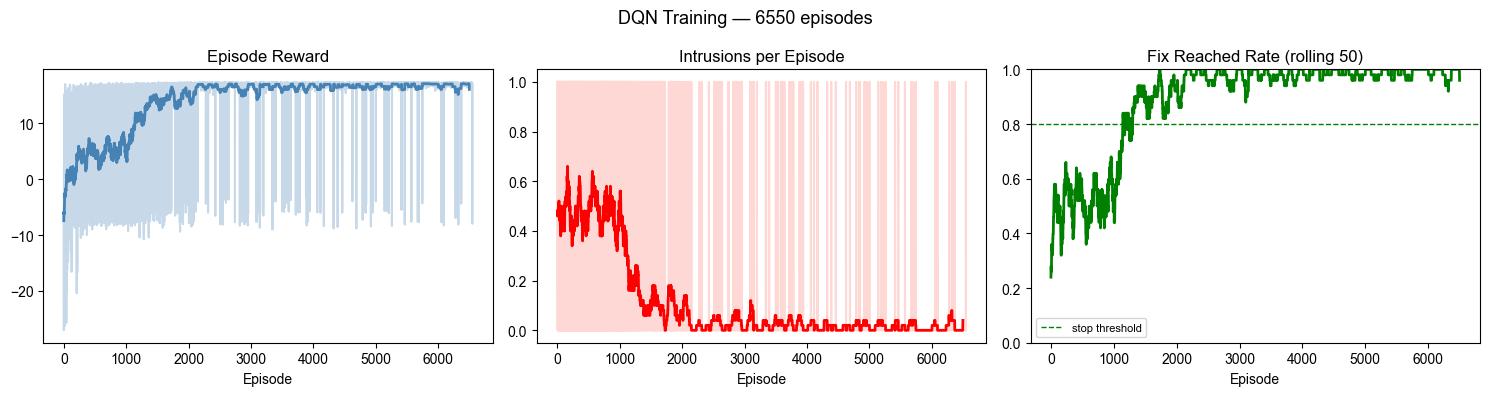

Episodes: 6550 | Avg reward (last 50): 16.107 | Fix reached: 48/50
Training complete ✓


In [148]:
# --- Callbacks --------------------------------------------------------
class LivePlotCallback(BaseCallback):
    """Plots reward and intrusions every N episodes during training."""
    def __init__(self, plot_every=50):
        super().__init__()
        self.plot_every = plot_every
        self.ep_rewards, self.ep_intrusions, self.ep_reached = [], [], []
        self._ep_reward = 0.0

    def _on_step(self):
        self._ep_reward += self.locals['rewards'][0]
        if self.locals['dones'][0]:
            info = self.locals['infos'][0]
            self.ep_rewards.append(self._ep_reward)
            self.ep_intrusions.append(info.get('total_intrusions', 0))
            self.ep_reached.append(int(info.get('reached_fix', False)))
            self._ep_reward = 0.0
            if len(self.ep_rewards) % self.plot_every == 0:
                self._plot()
        return True

    def _plot(self):
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        n = len(self.ep_rewards)
        window = min(50, n)
        axes[0].plot(self.ep_rewards, alpha=0.3, color='steelblue')
        axes[0].plot(np.convolve(self.ep_rewards, np.ones(window)/window, mode='valid'),
                     color='steelblue', linewidth=2)
        axes[0].set_title('Episode Reward'); axes[0].set_xlabel('Episode')
        axes[1].plot(self.ep_intrusions, alpha=0.3, color='salmon')
        axes[1].plot(np.convolve(self.ep_intrusions, np.ones(window)/window, mode='valid'),
                     color='red', linewidth=2)
        axes[1].set_title('Intrusions per Episode'); axes[1].set_xlabel('Episode')
        axes[2].plot(np.convolve(self.ep_reached, np.ones(window)/window, mode='valid'),
                     color='green', linewidth=2)
        axes[2].axhline(0.8, color='green', linestyle='--', linewidth=1, label='stop threshold')
        axes[2].set_title(f'Fix Reached Rate (rolling {window})'); axes[2].set_xlabel('Episode')
        axes[2].set_ylim(0, 1); axes[2].legend(fontsize=8)
        plt.suptitle(f'DQN Training — {n} episodes', fontsize=13)
        plt.tight_layout(); plt.show()
        print(f'Episodes: {n} | Avg reward (last {window}): {np.mean(self.ep_rewards[-window:]):.3f} | '
              f'Fix reached: {sum(self.ep_reached[-window:])}/{window}')


# --- Build and train DQN -----------------------------------------------
train_env = DiscreteApproachEnv()
callbacks = LivePlotCallback(plot_every=50)

model = DQN(
    policy               = 'MultiInputPolicy',
    env                  = train_env,
    learning_rate        = 5e-4,
    buffer_size          = 100_000,
    learning_starts      = 500,
    batch_size           = 128,
    gamma                = 0.99,
    exploration_fraction = 0.5,   # longer exploration — avoidance is hard to discover
    exploration_final_eps= 0.05,
    train_freq           = 4,
    target_update_interval = 1000,
    verbose              = 0,
)

print('Training DQN for up to 100k steps...')
model.learn(total_timesteps=100_000, callback=callbacks)
print('Training complete ✓')

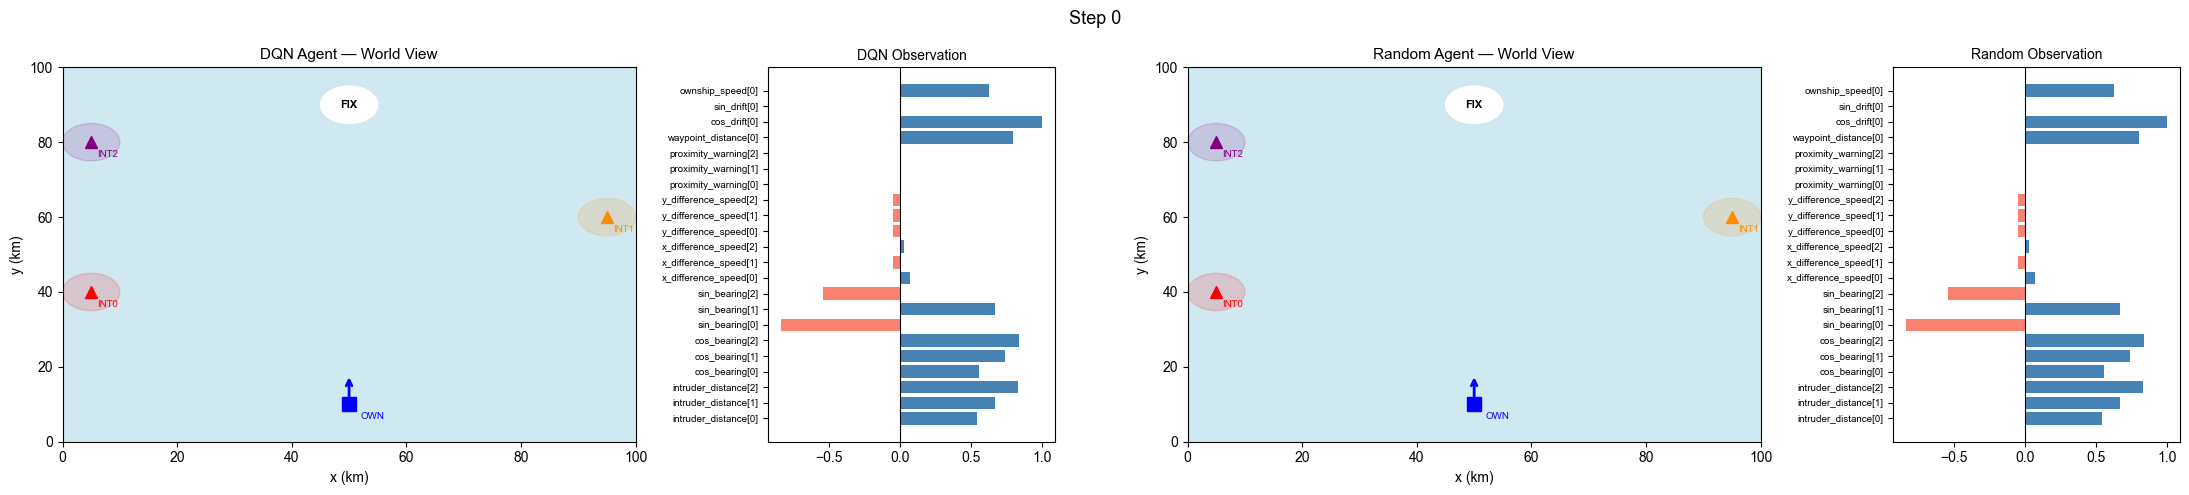

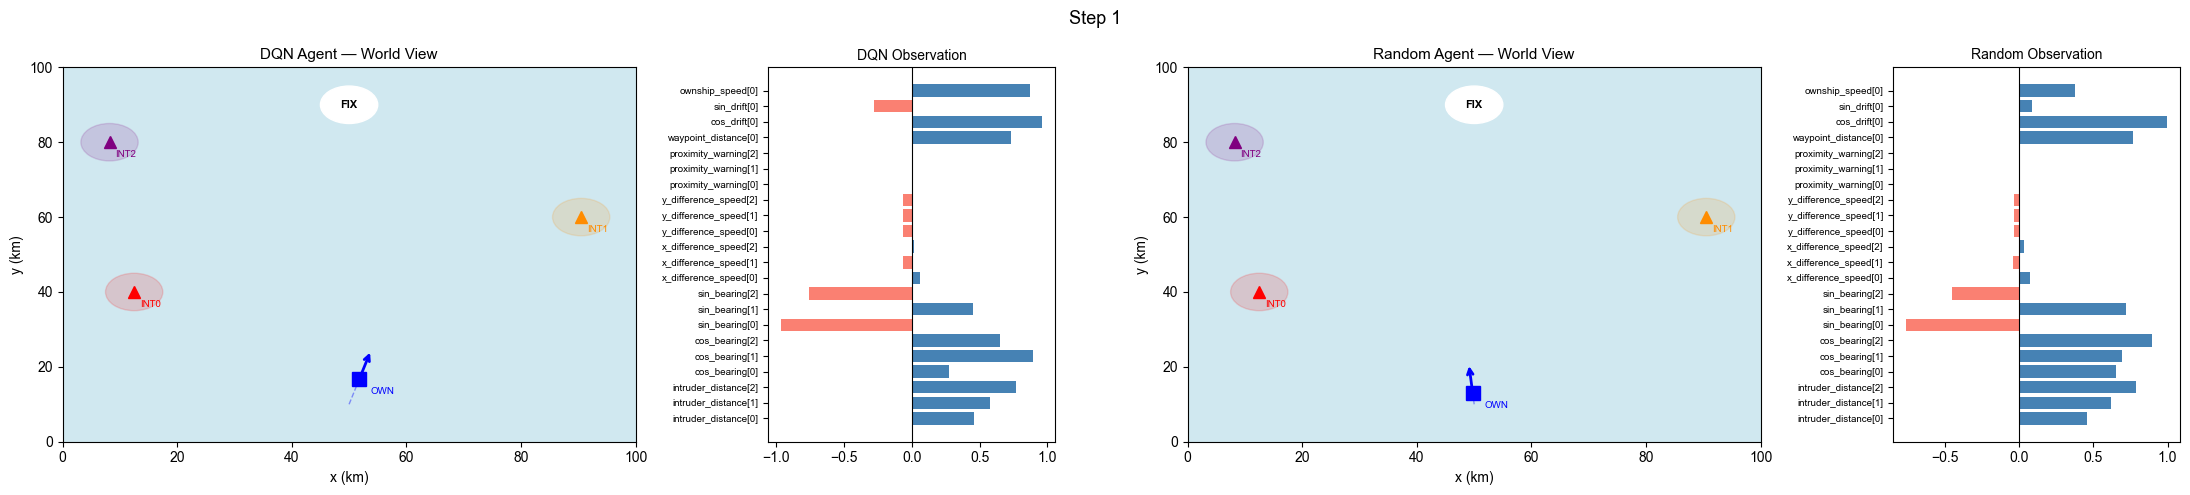

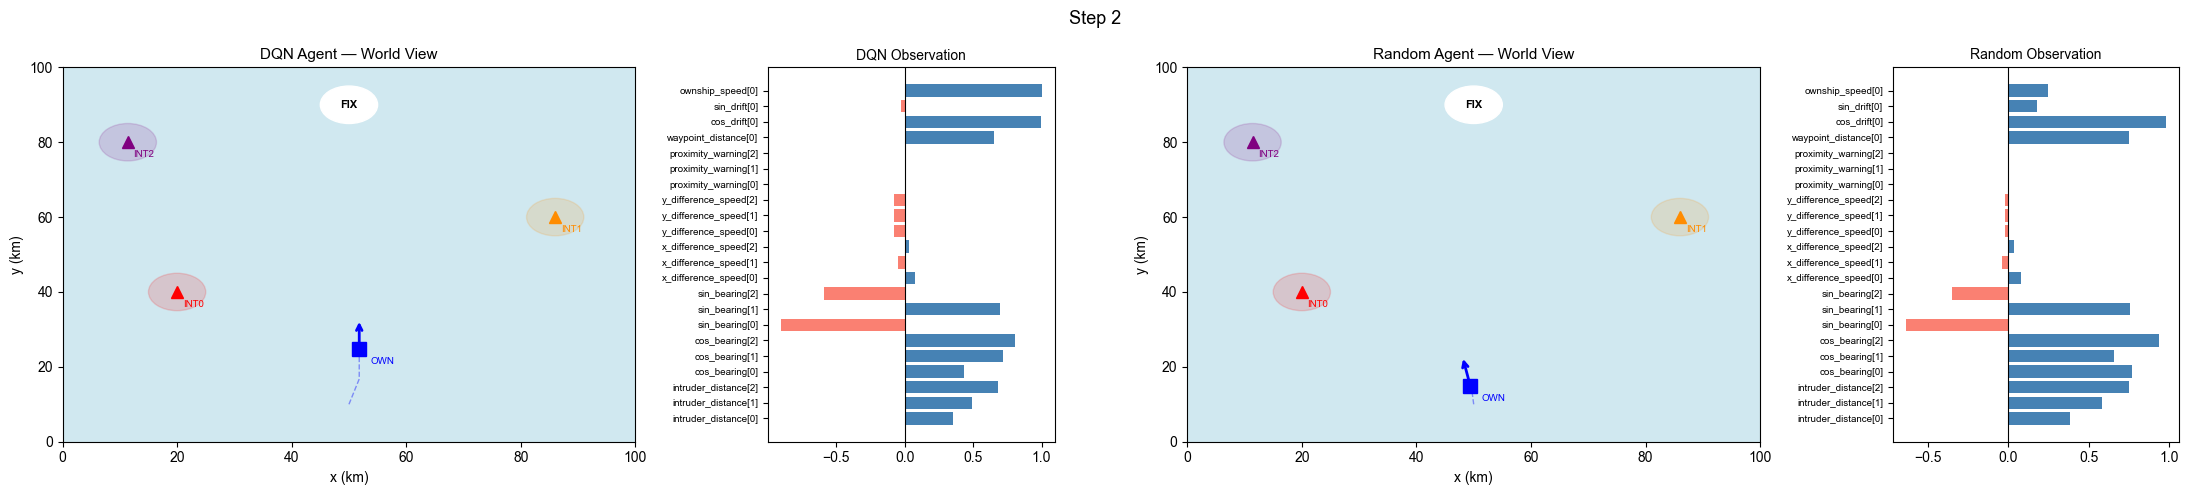

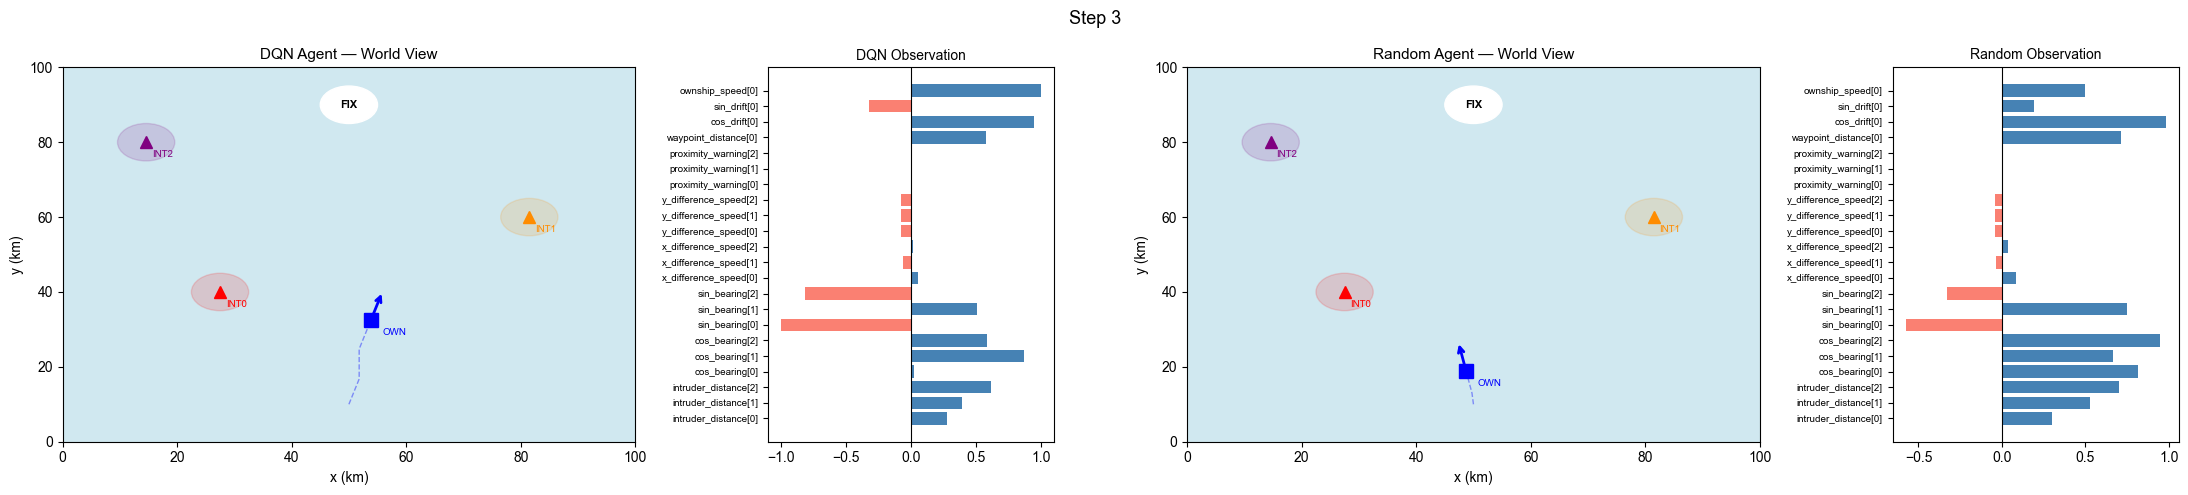

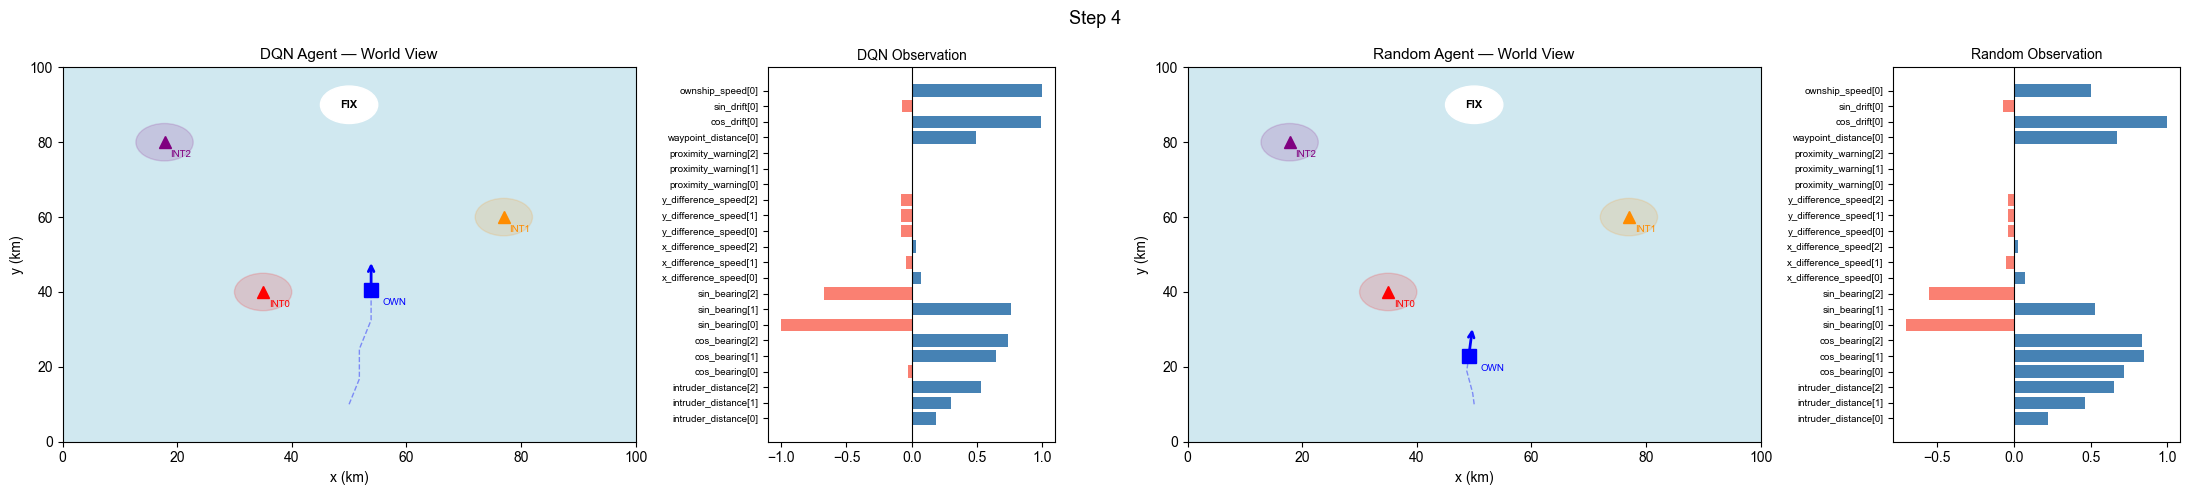

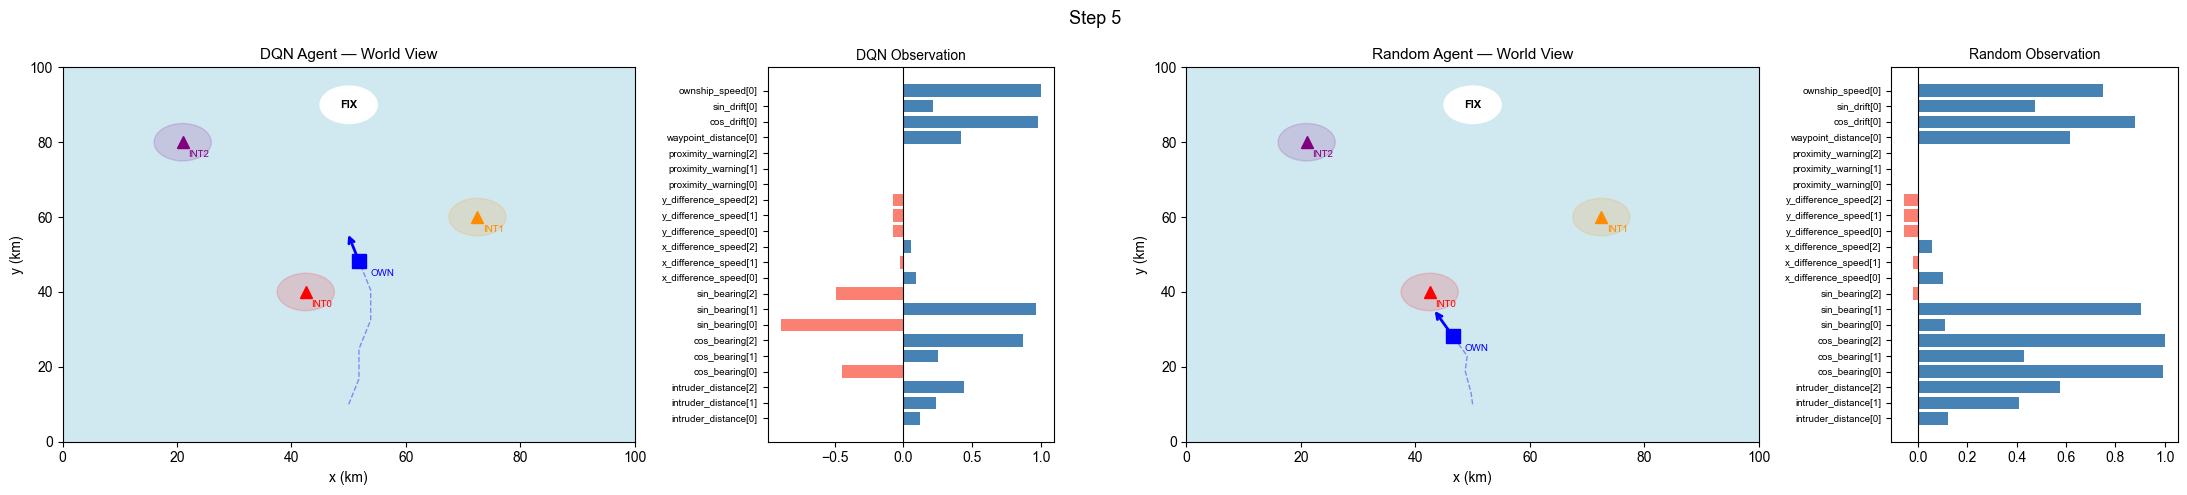

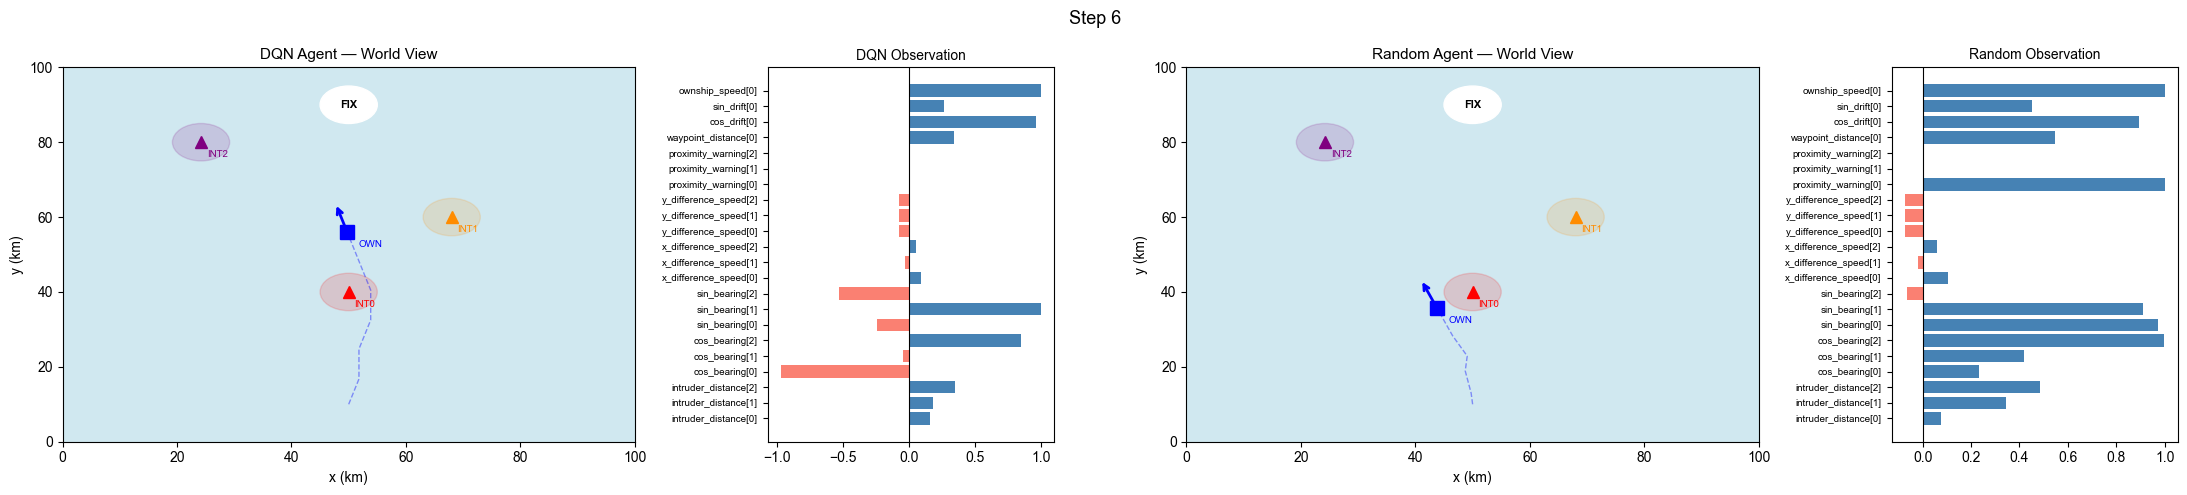

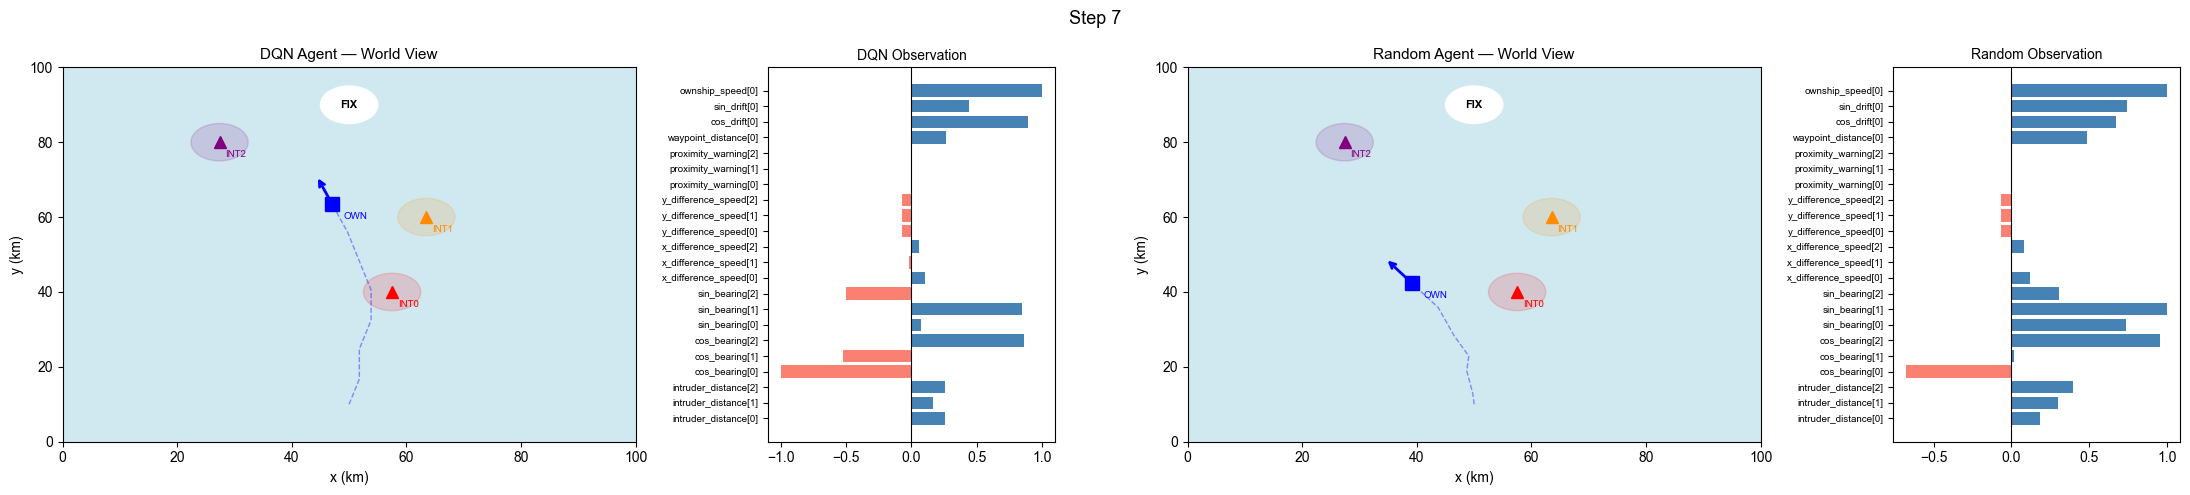

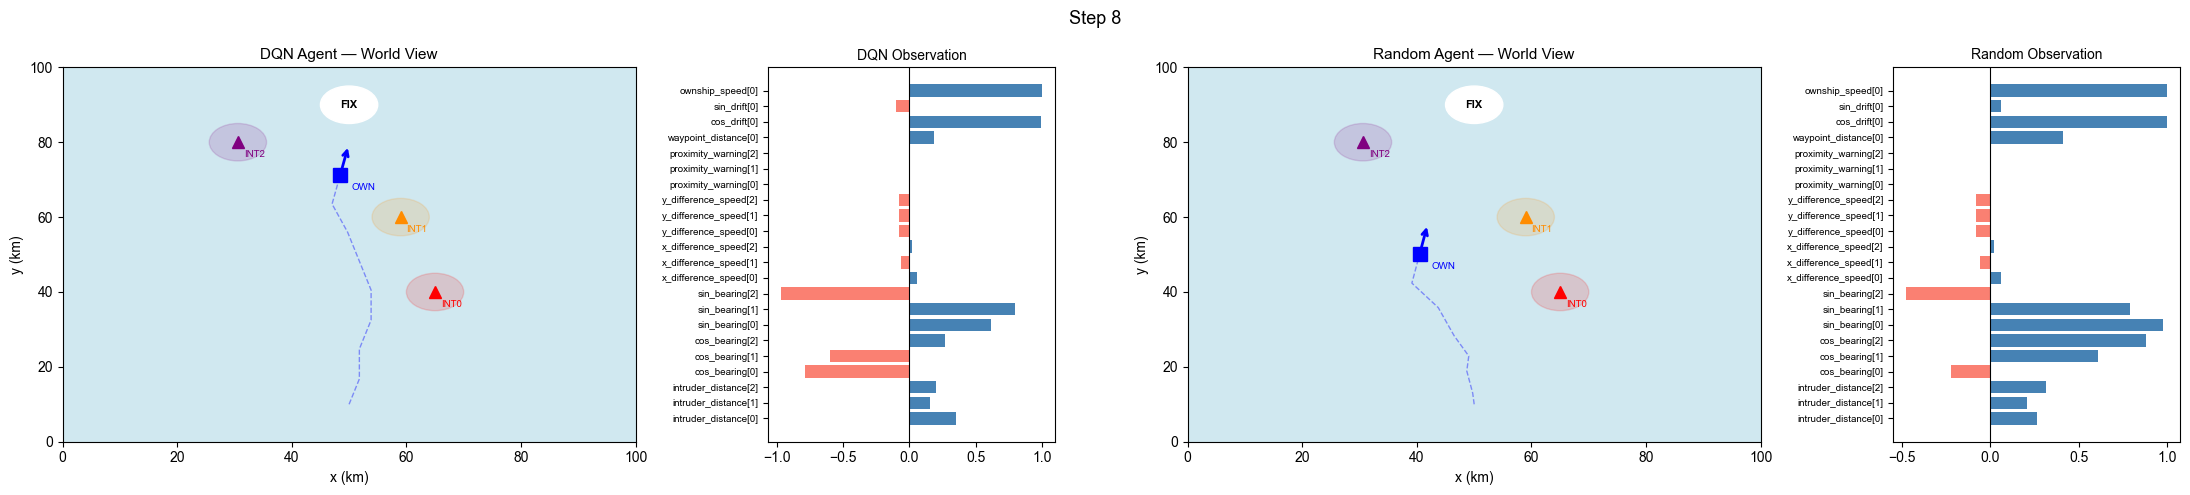

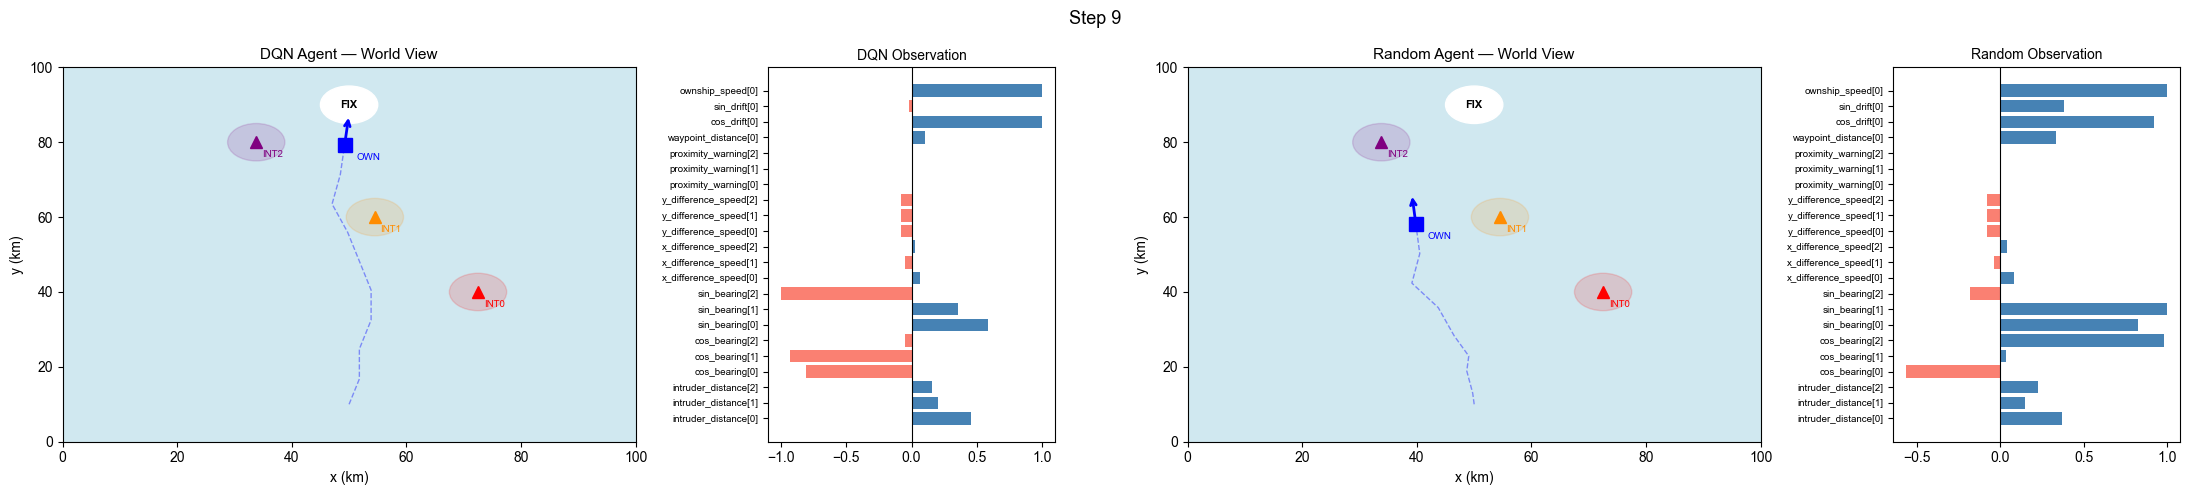

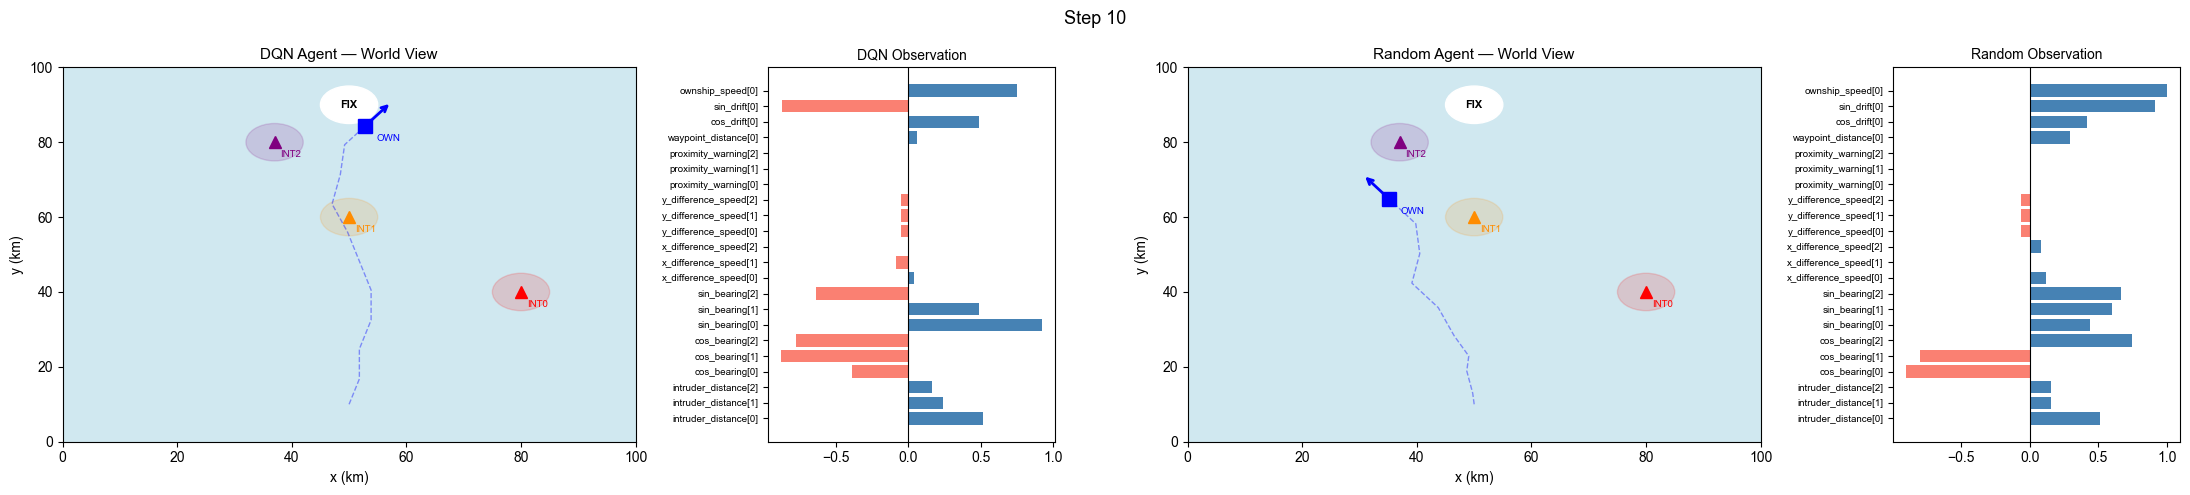

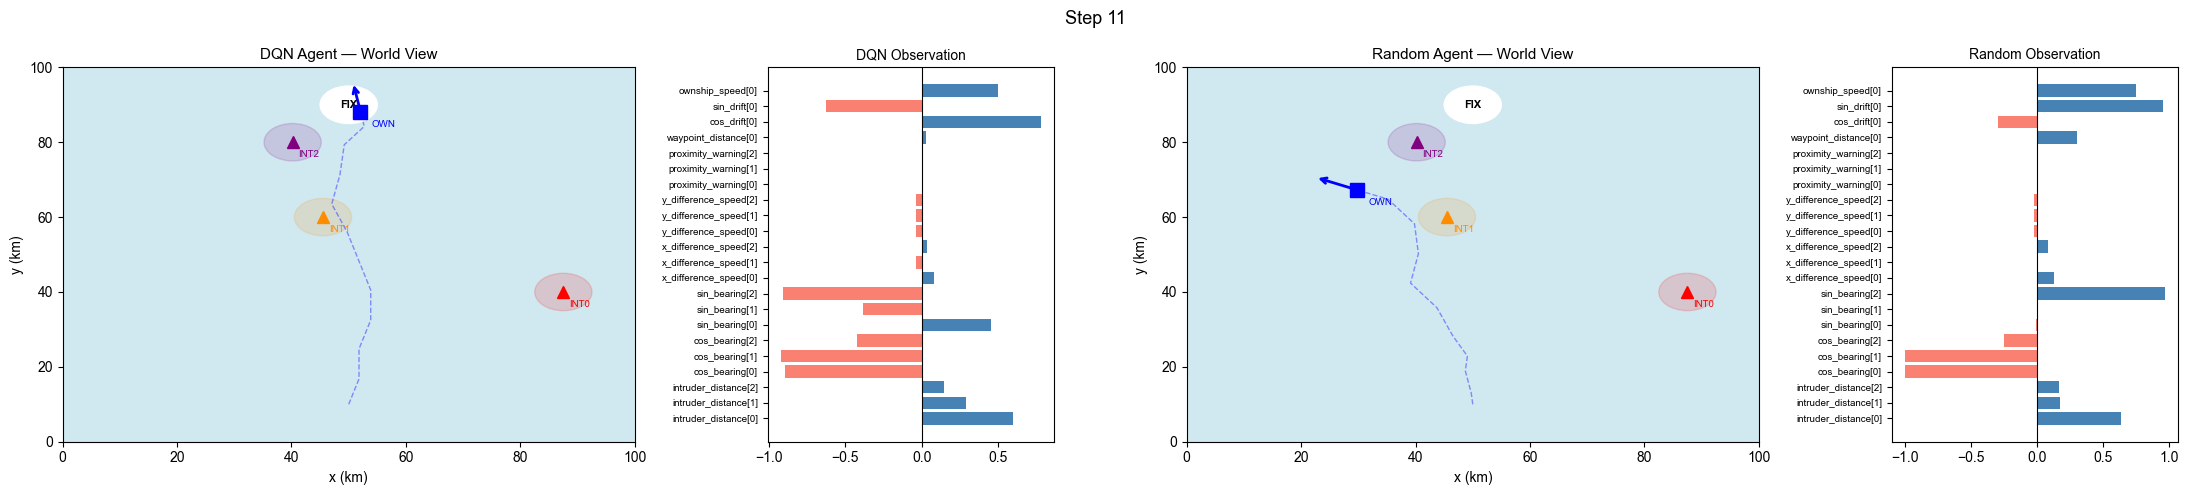

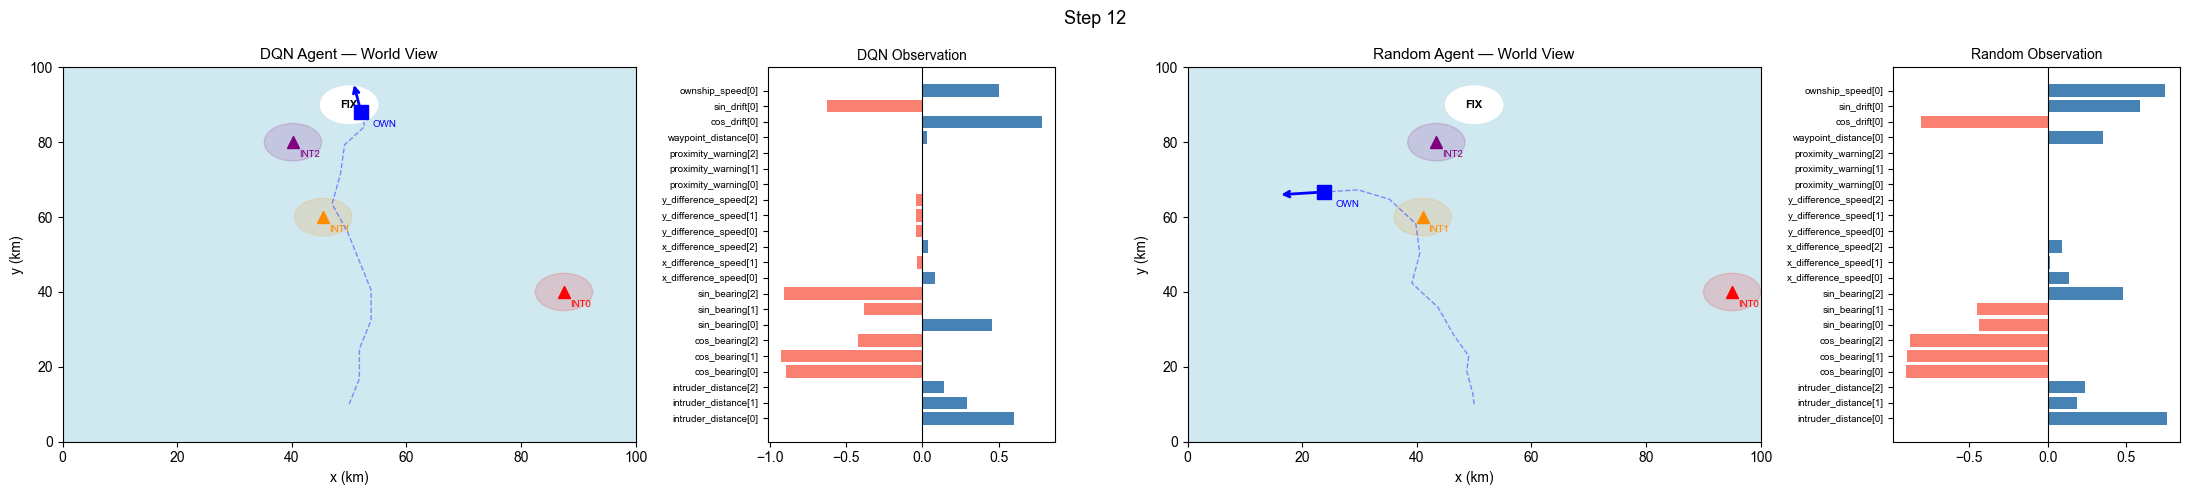

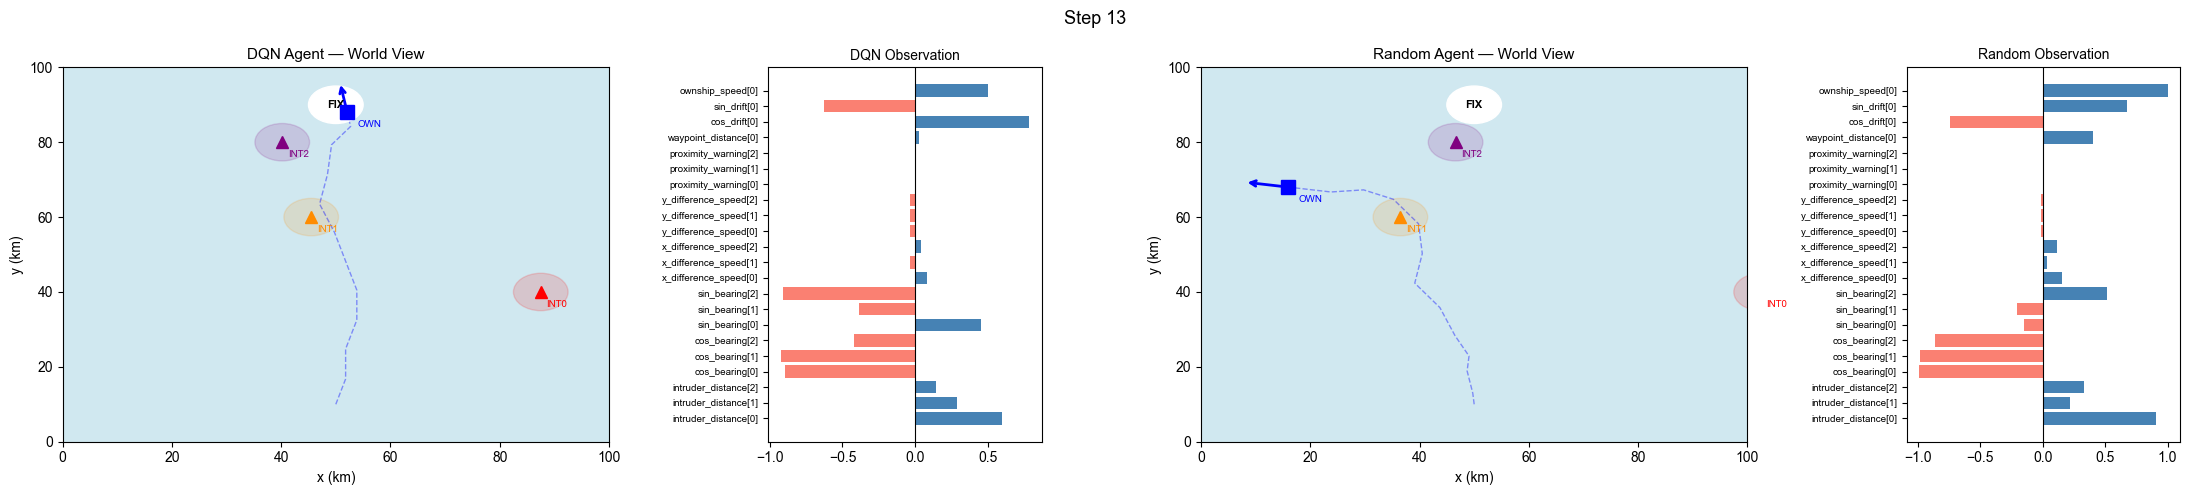

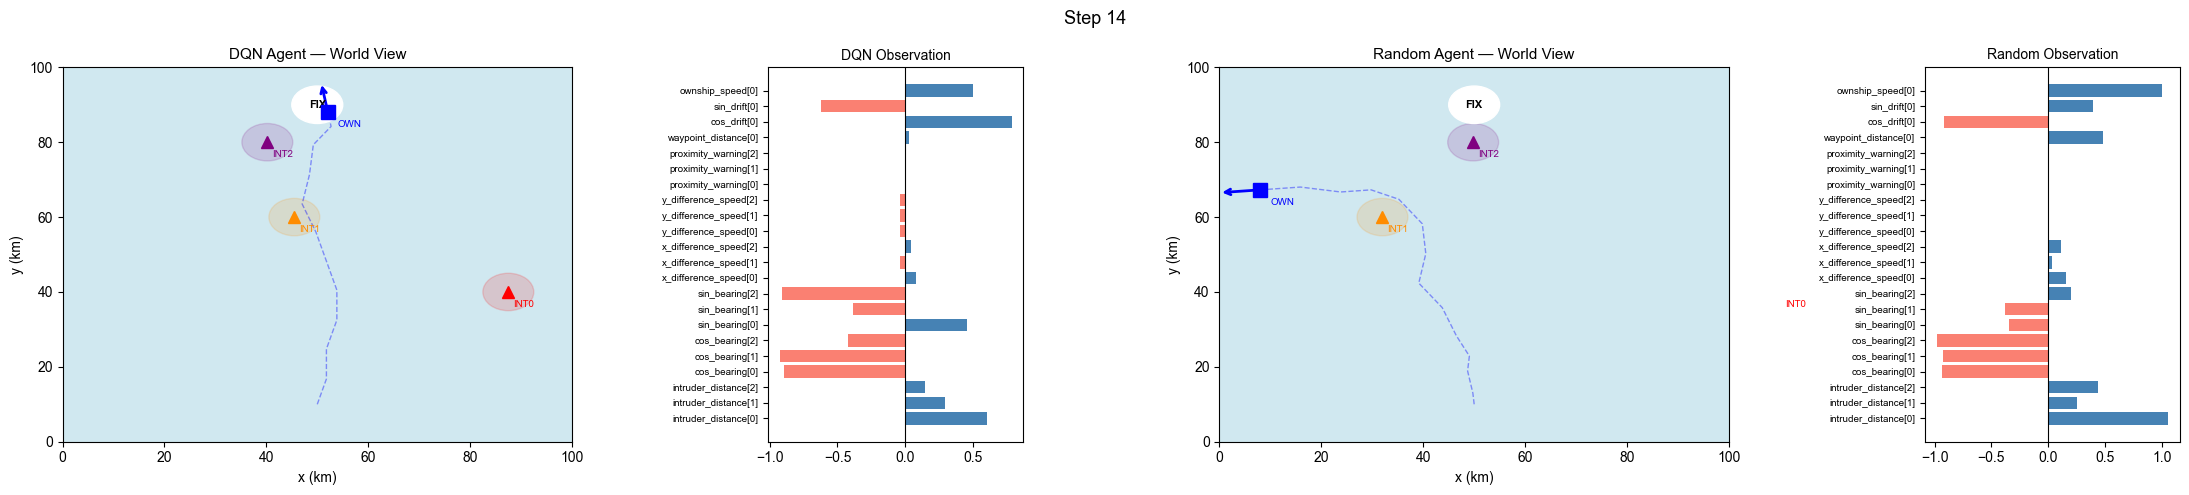

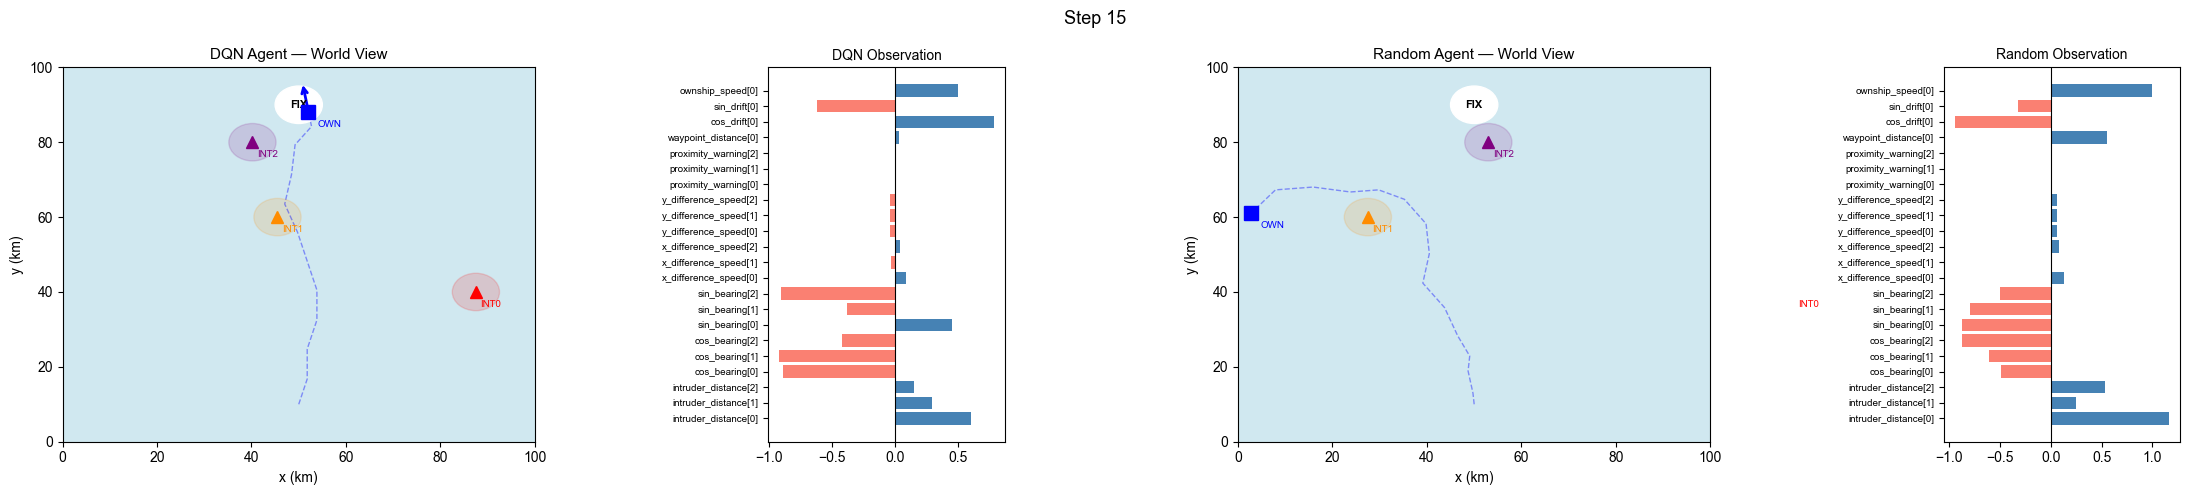

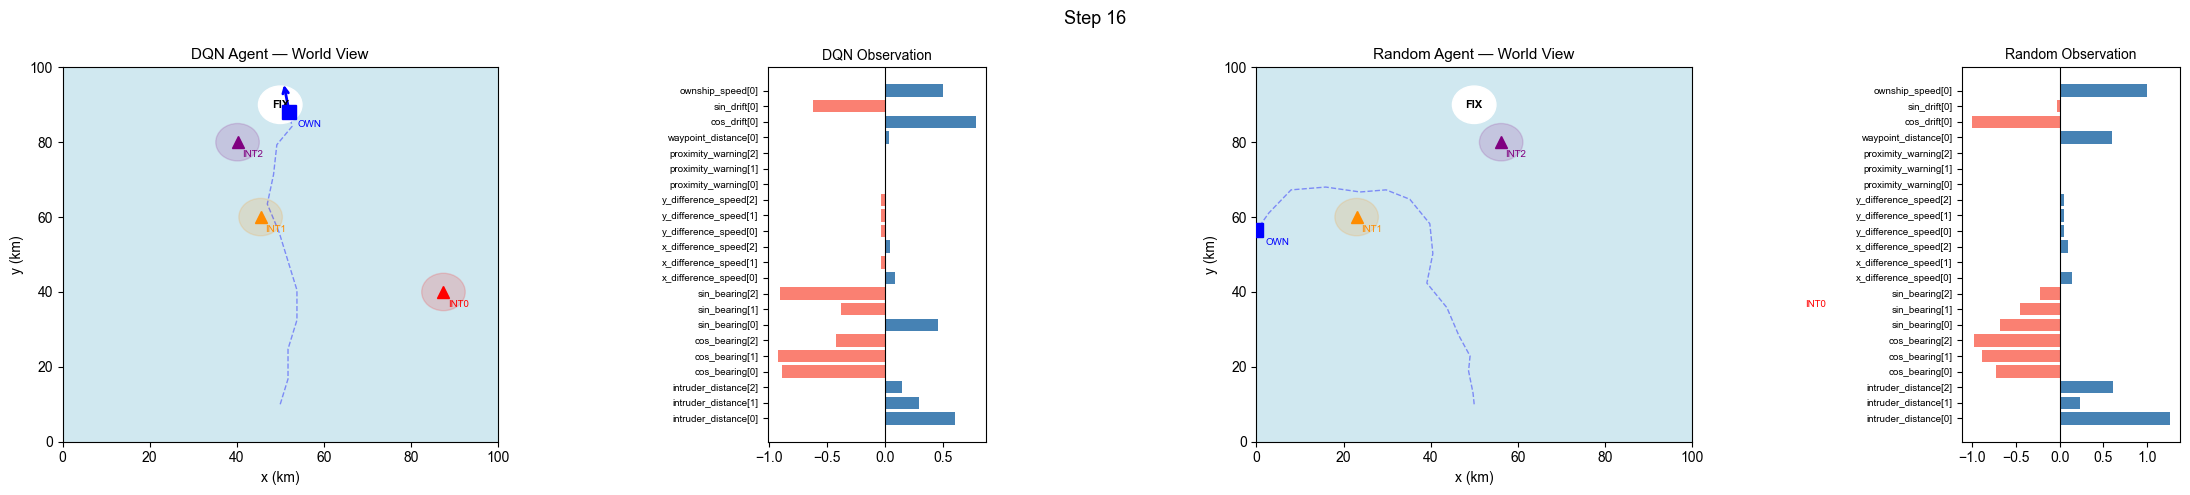

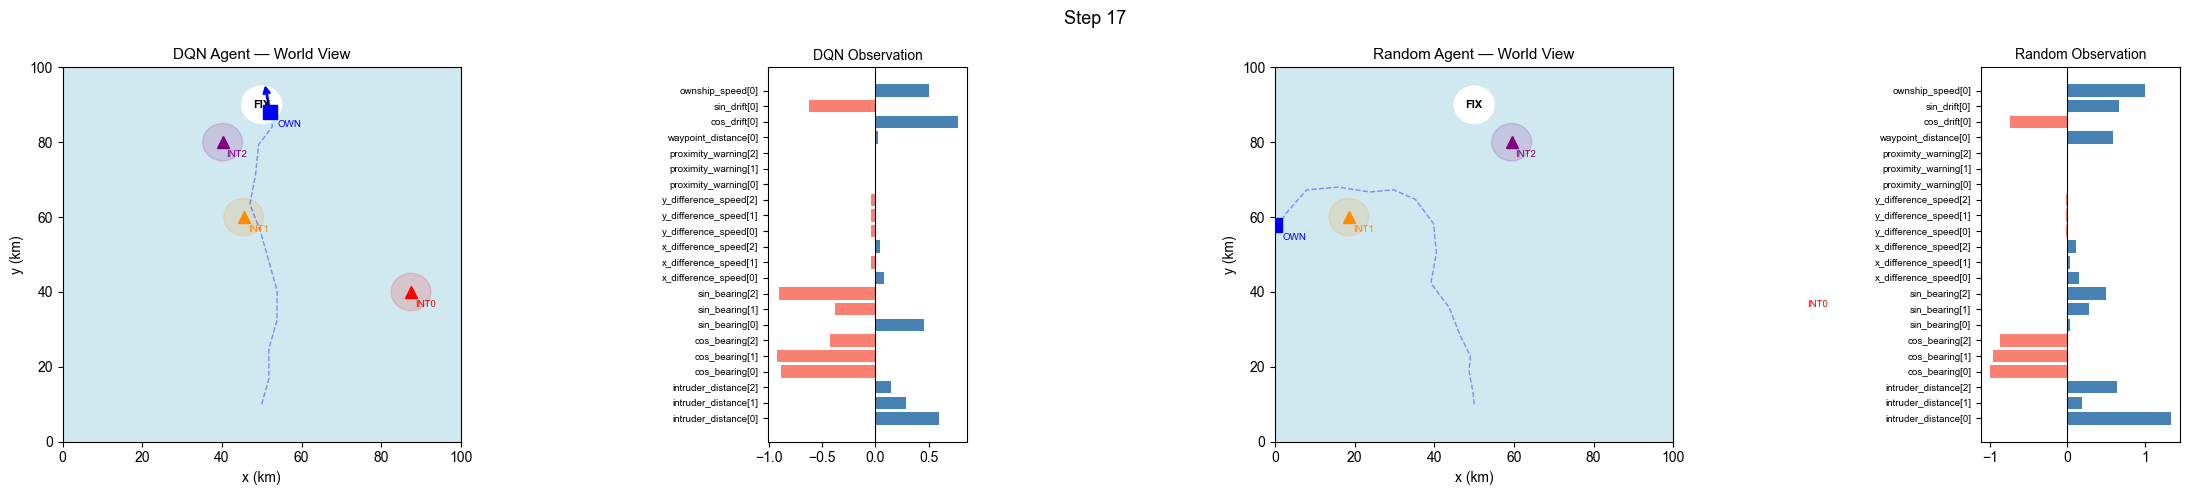

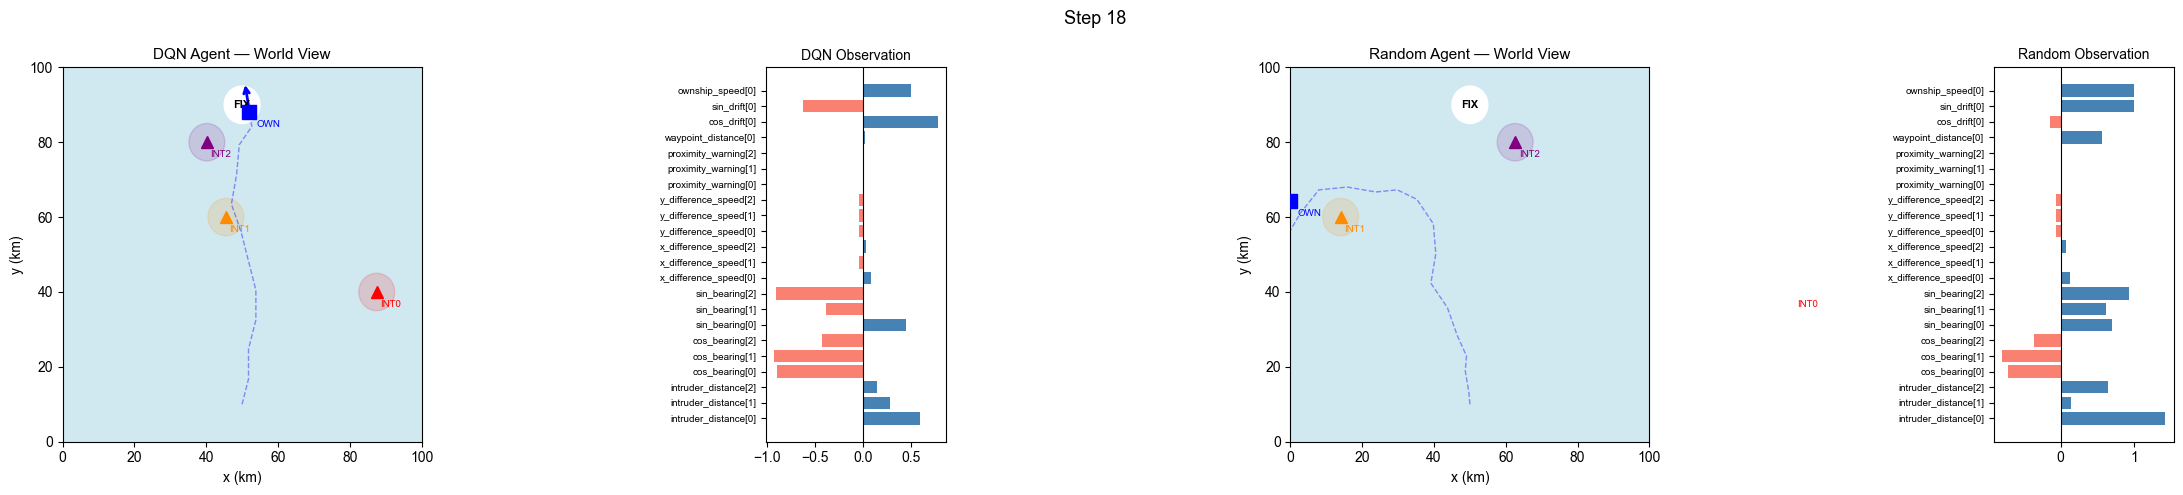

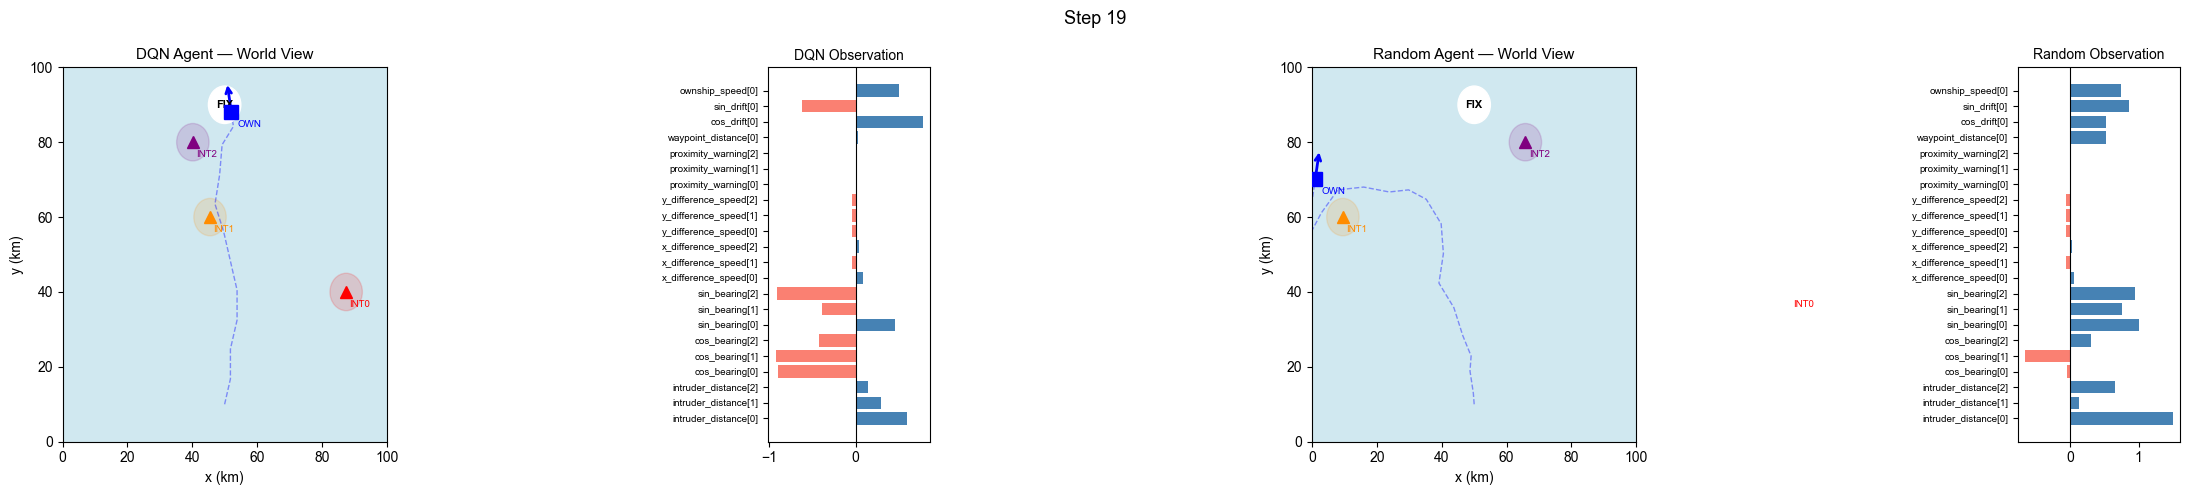

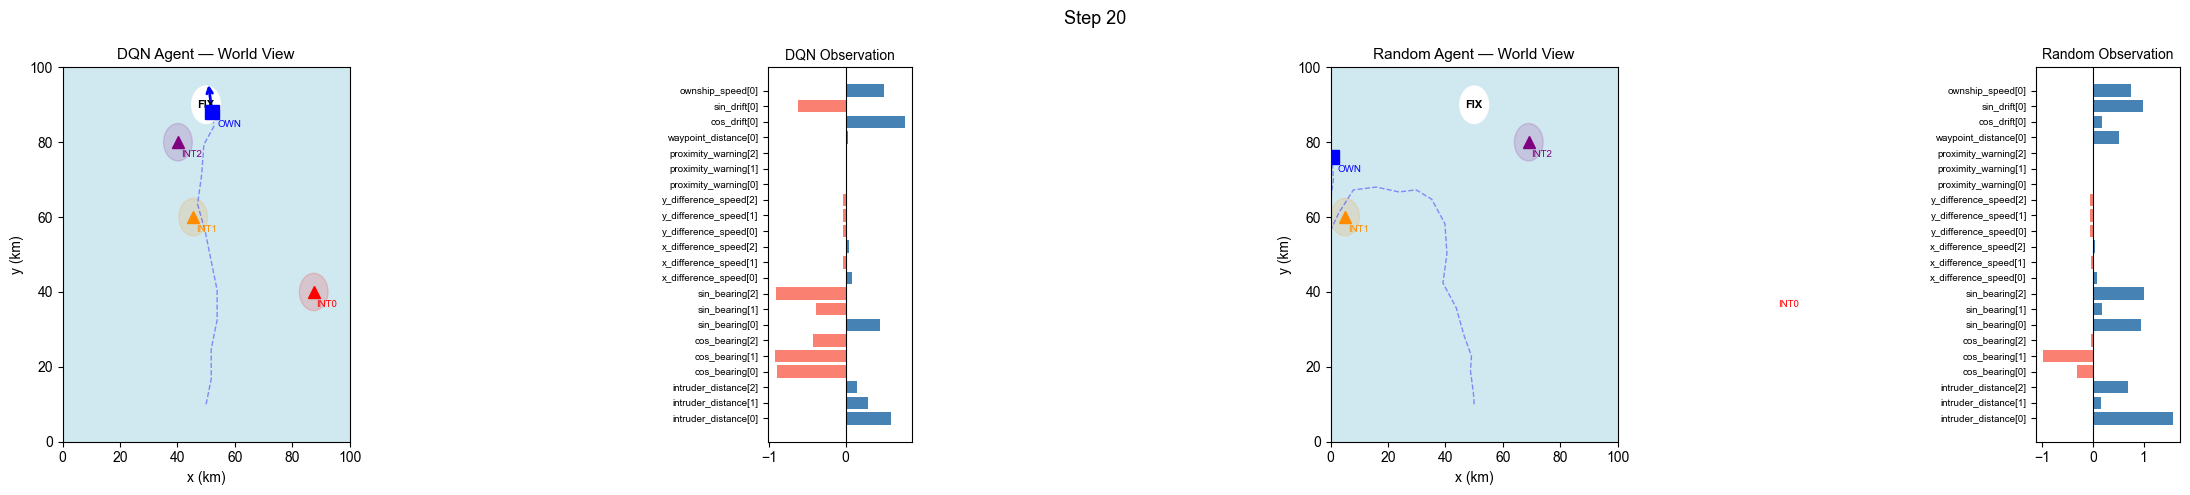

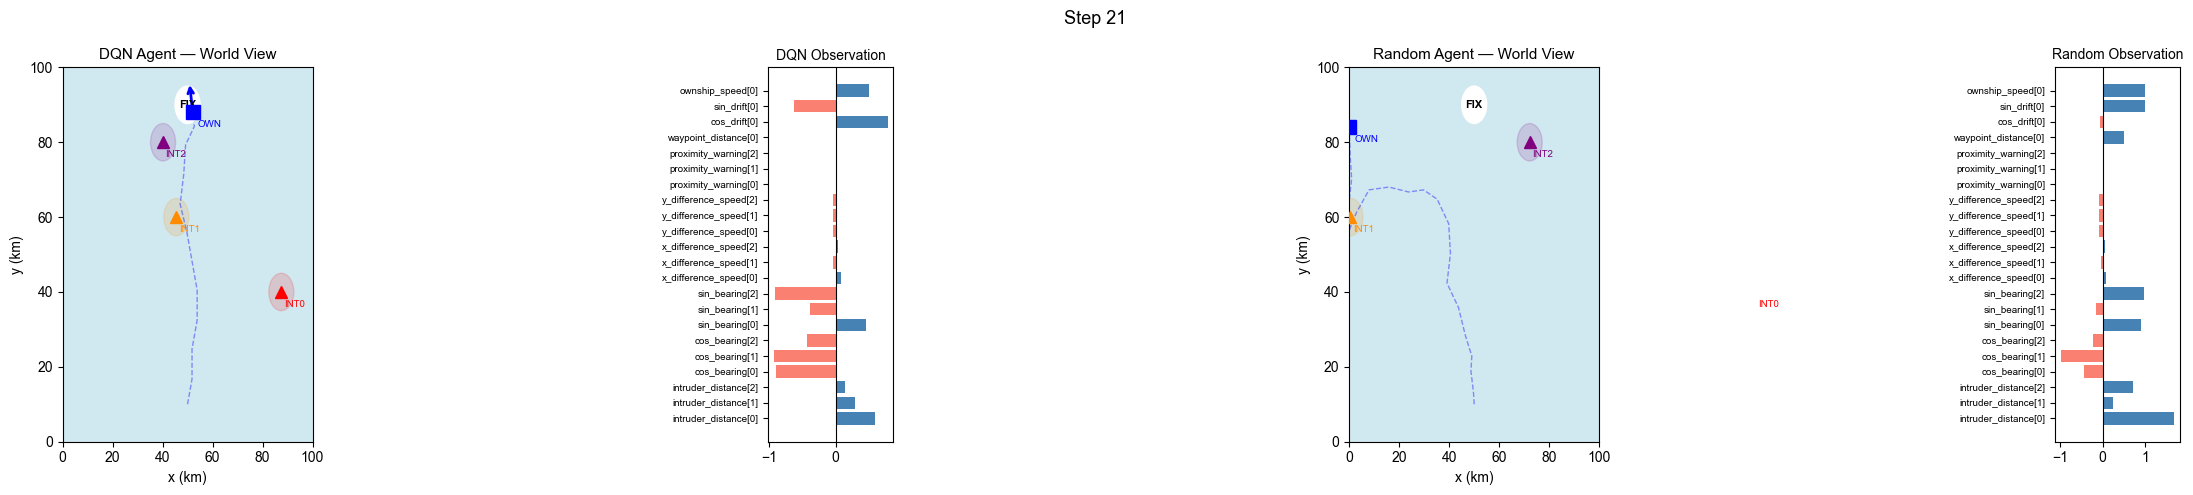

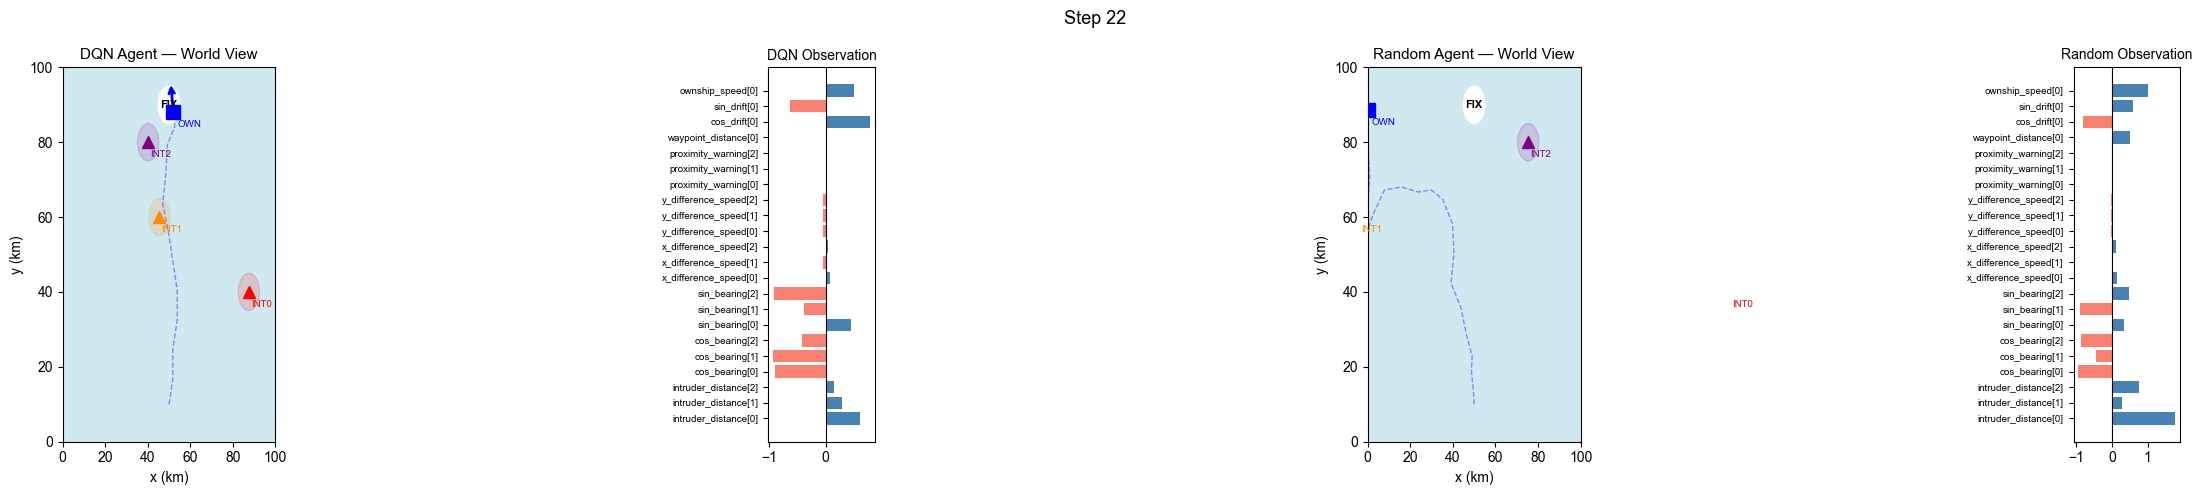

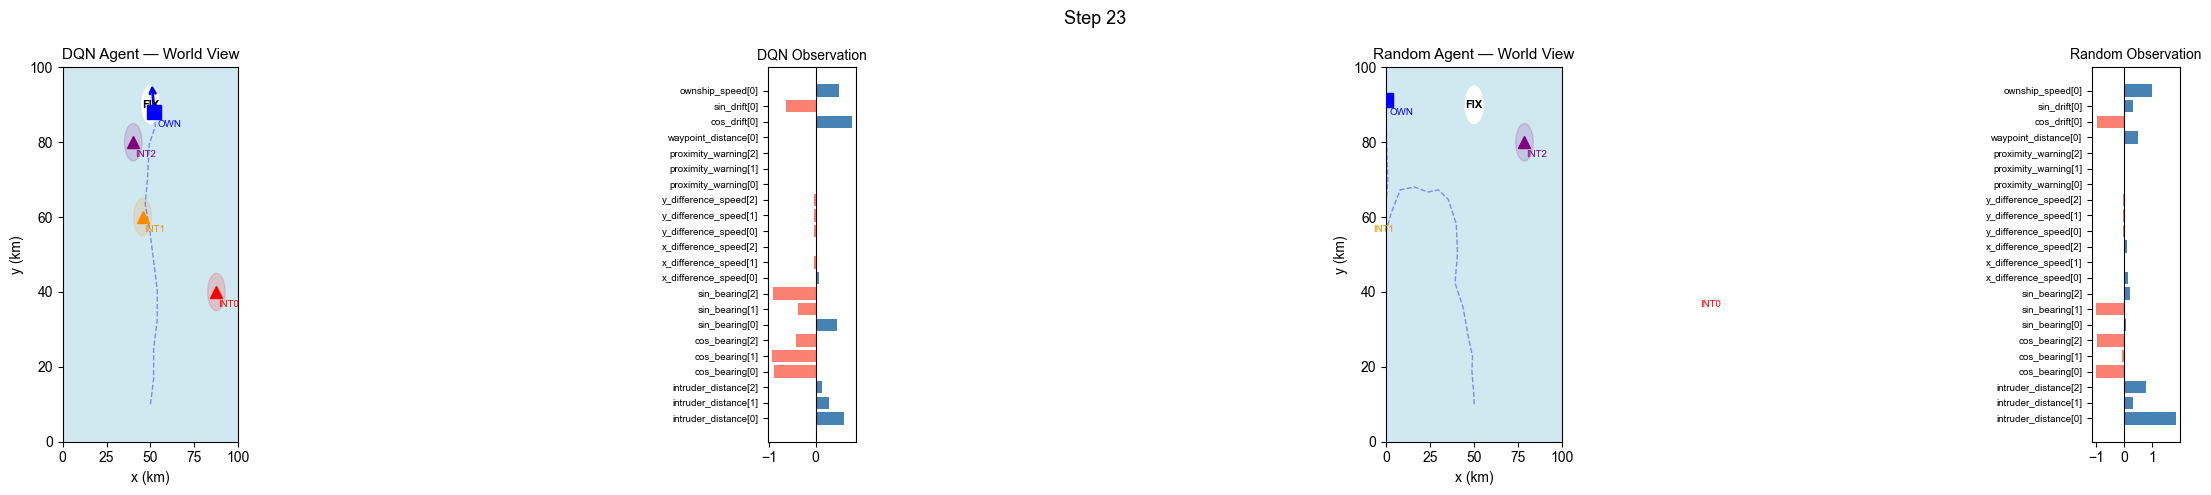

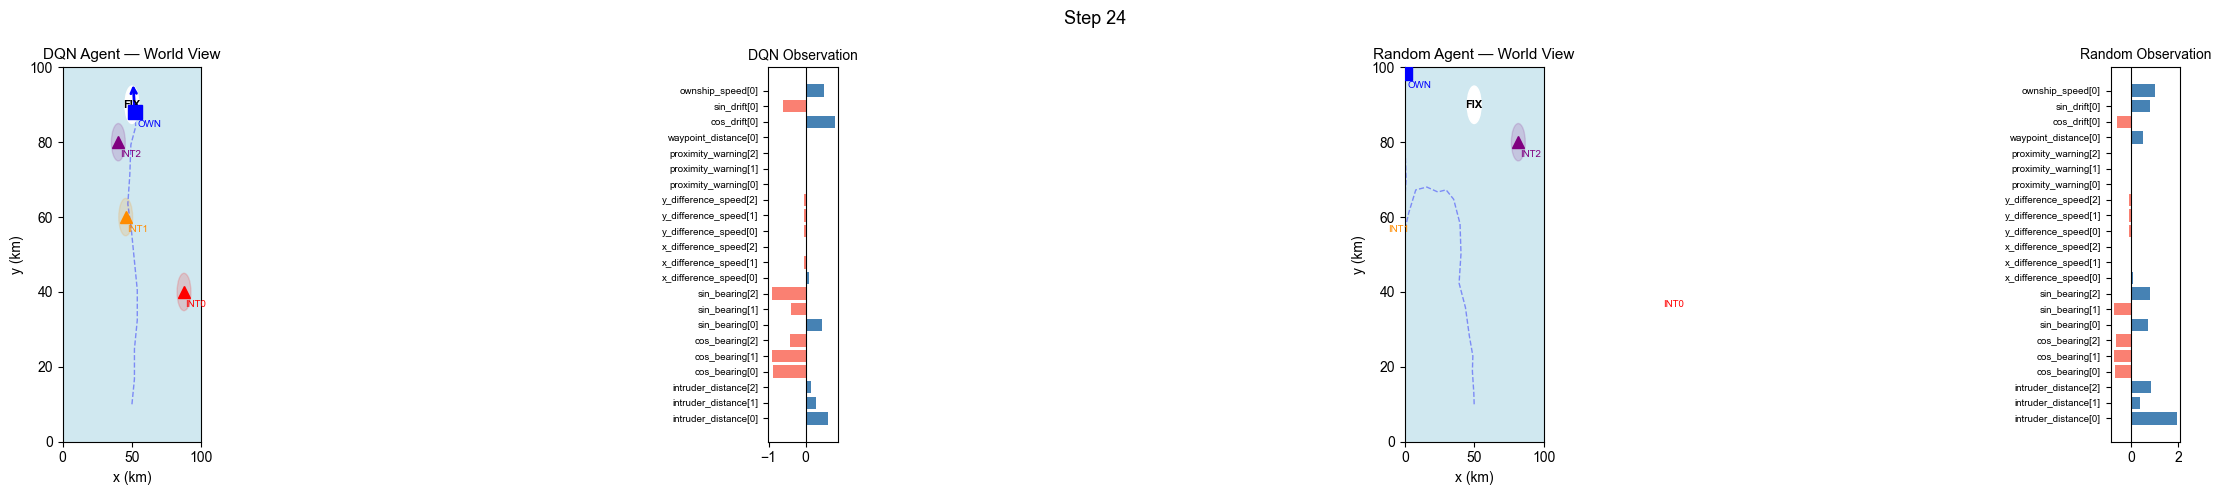

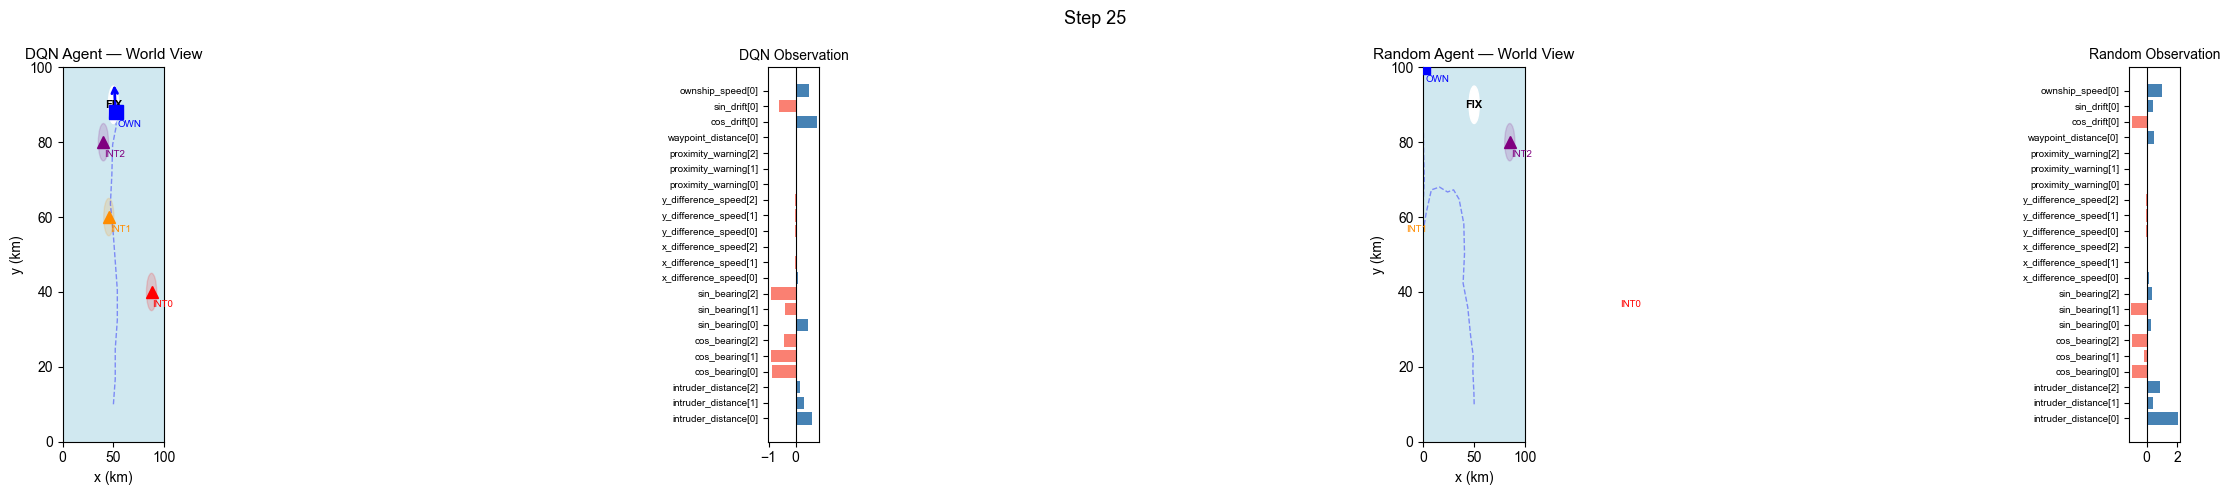

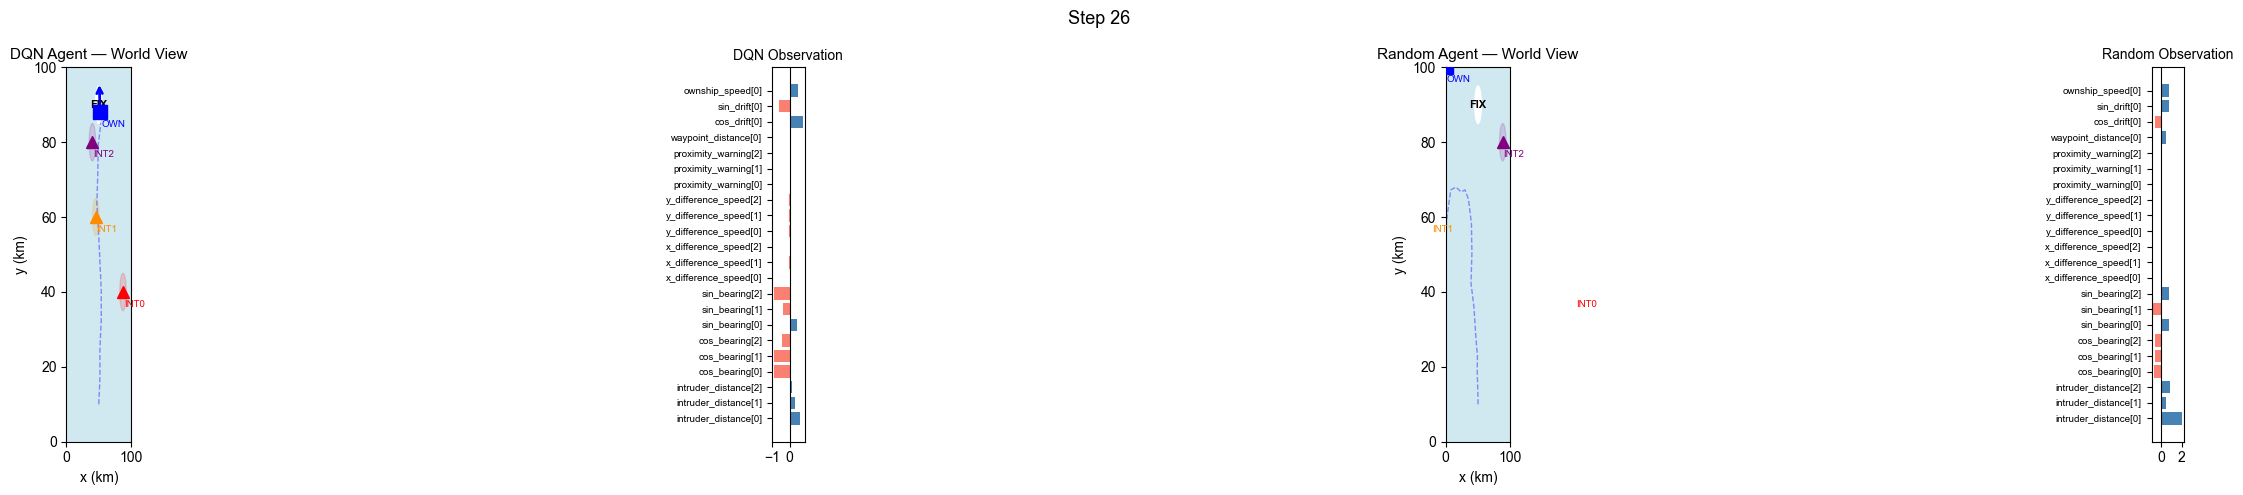

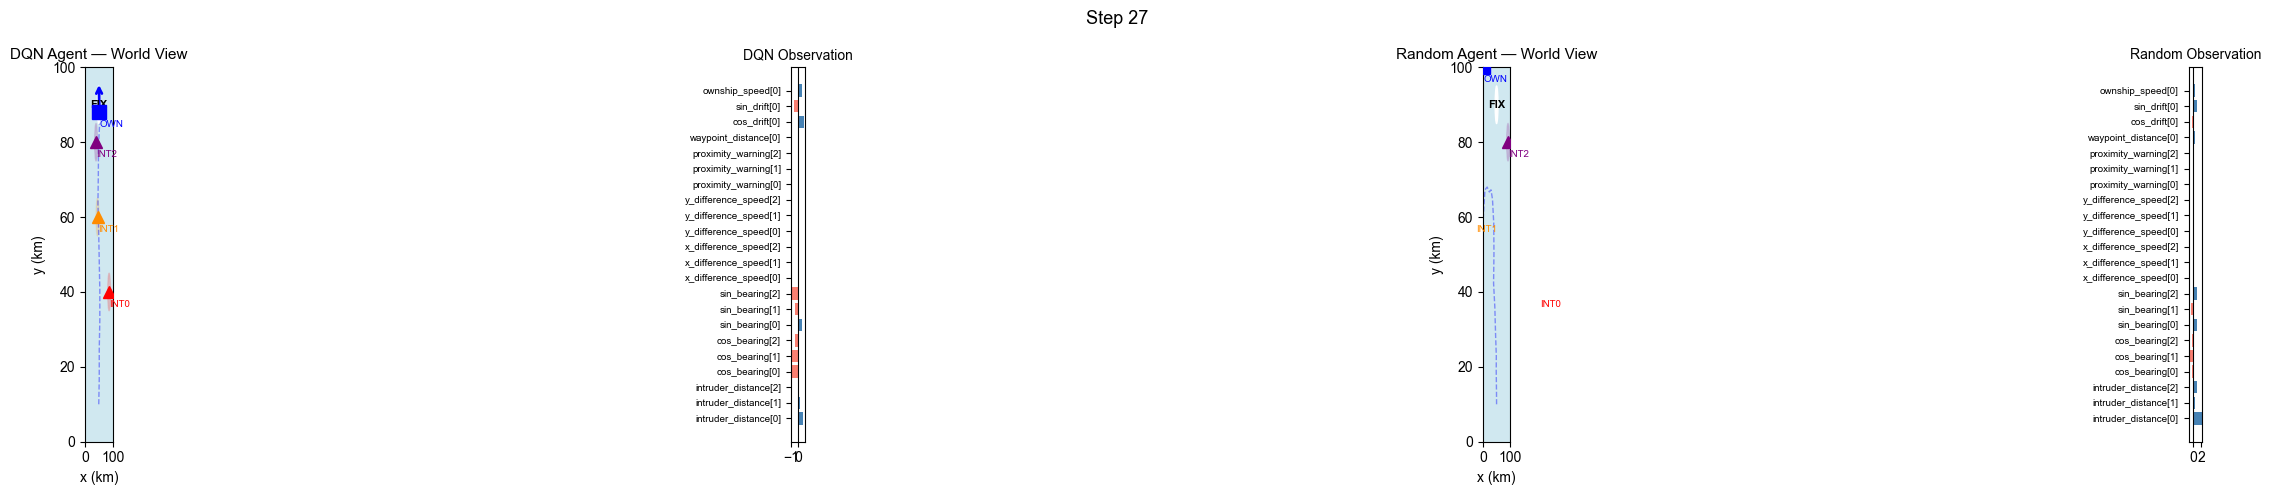

/var/folders/8l/1_h4wwj51v7_3m806s37pc_h0000gq/T/ipykernel_16166/3207507147.py:52: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


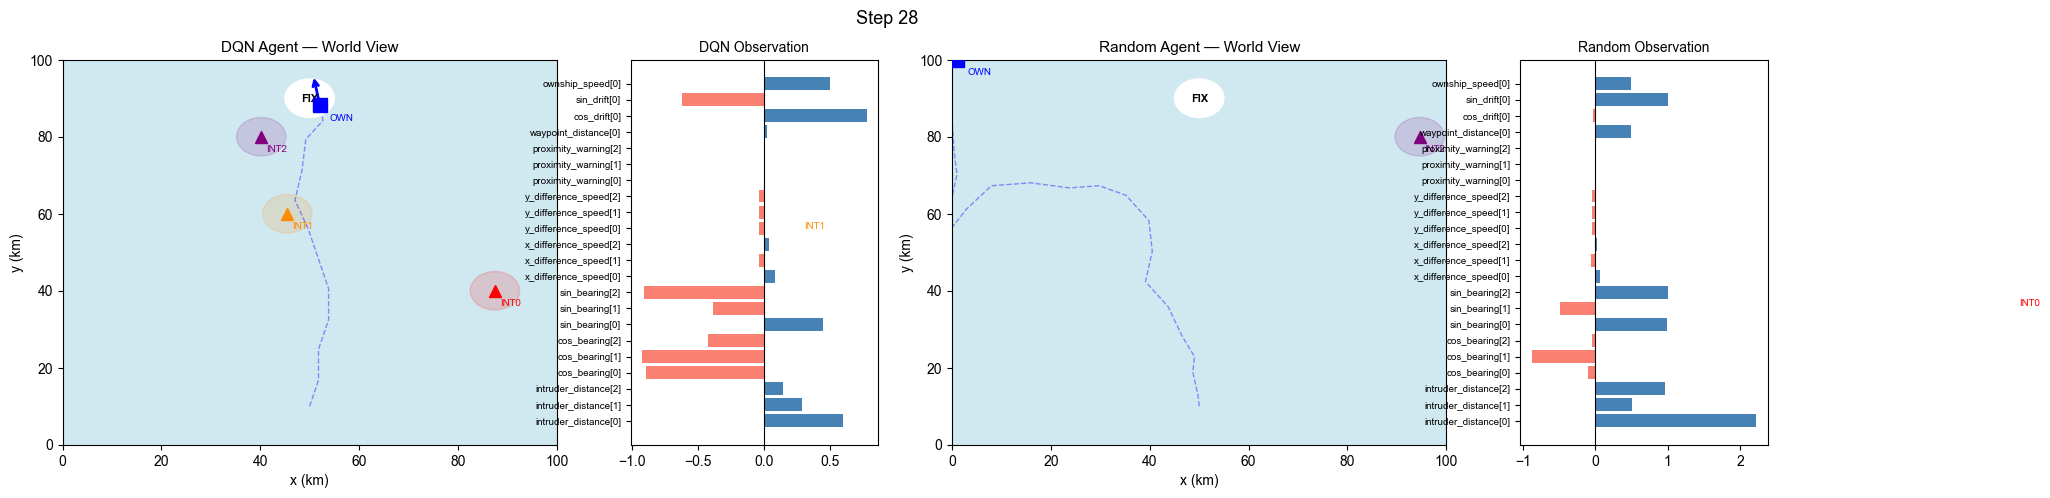

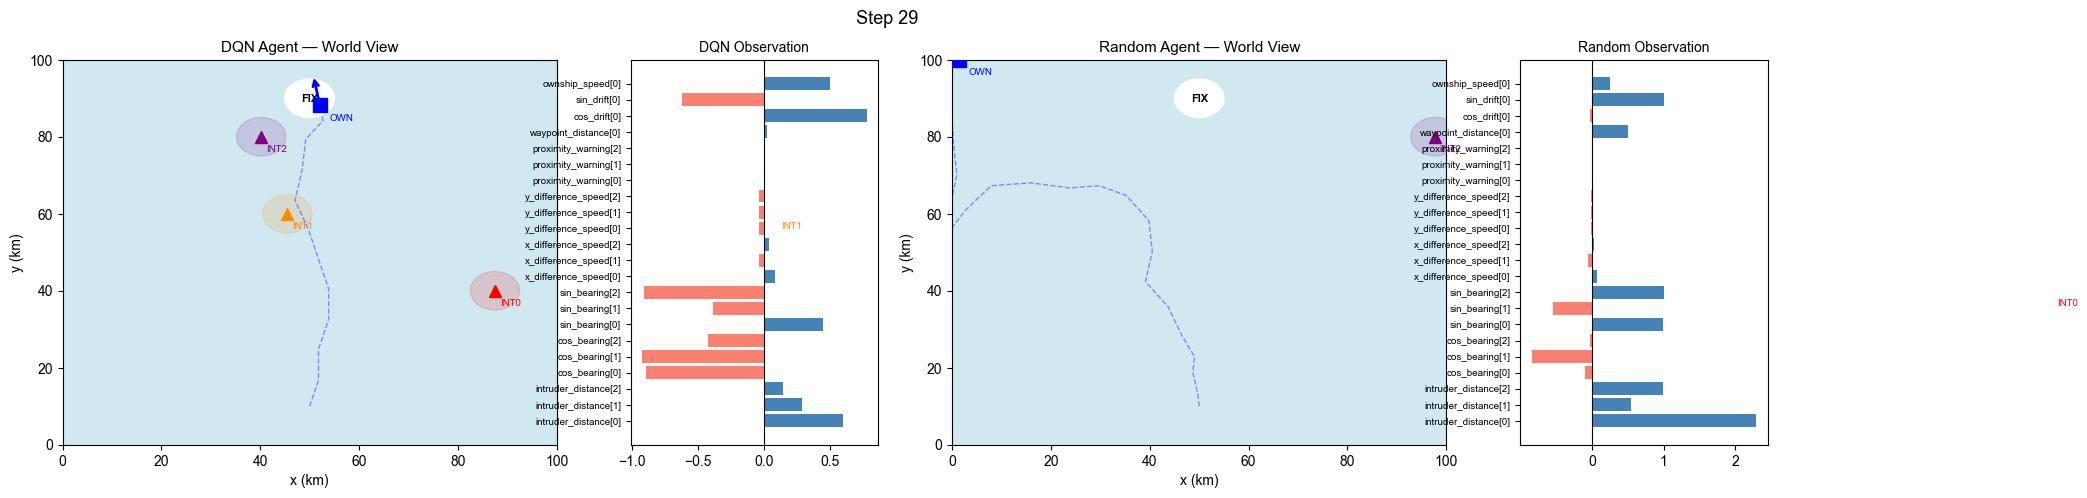

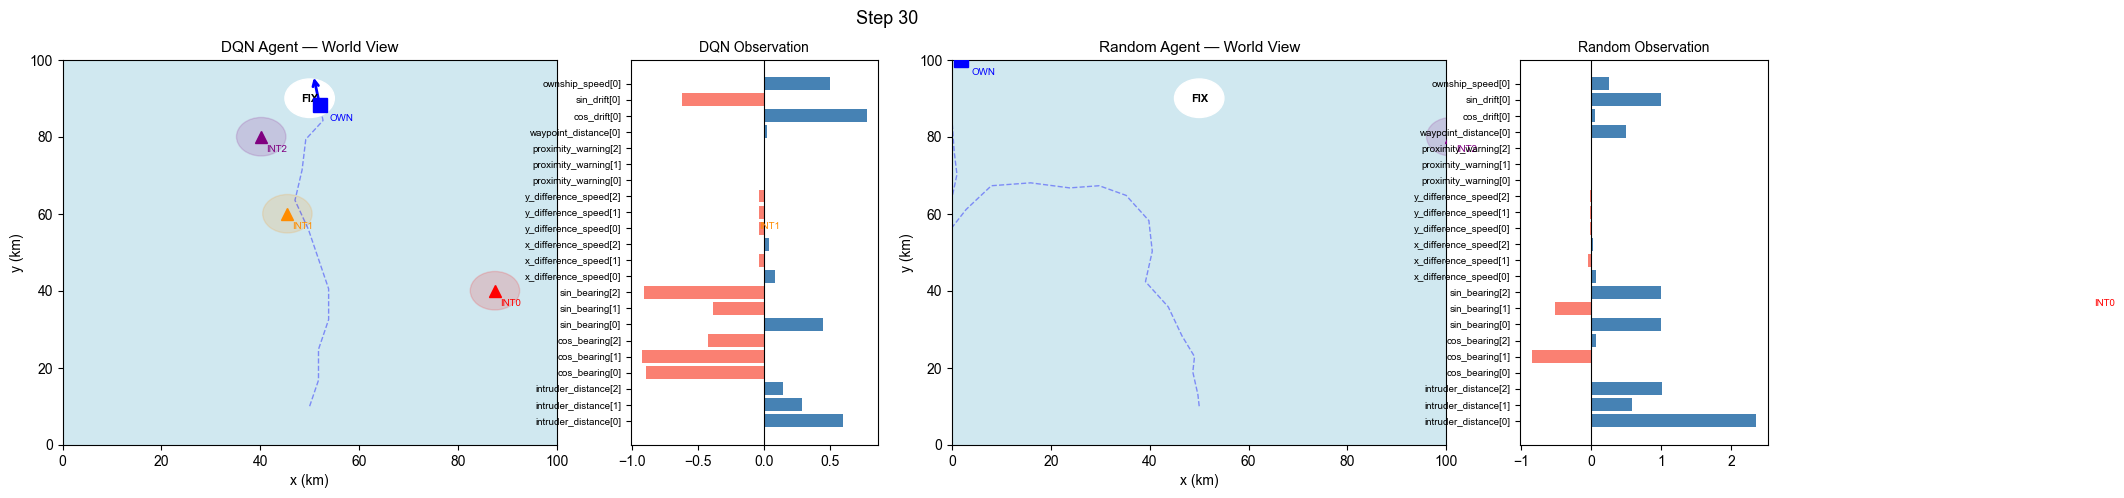

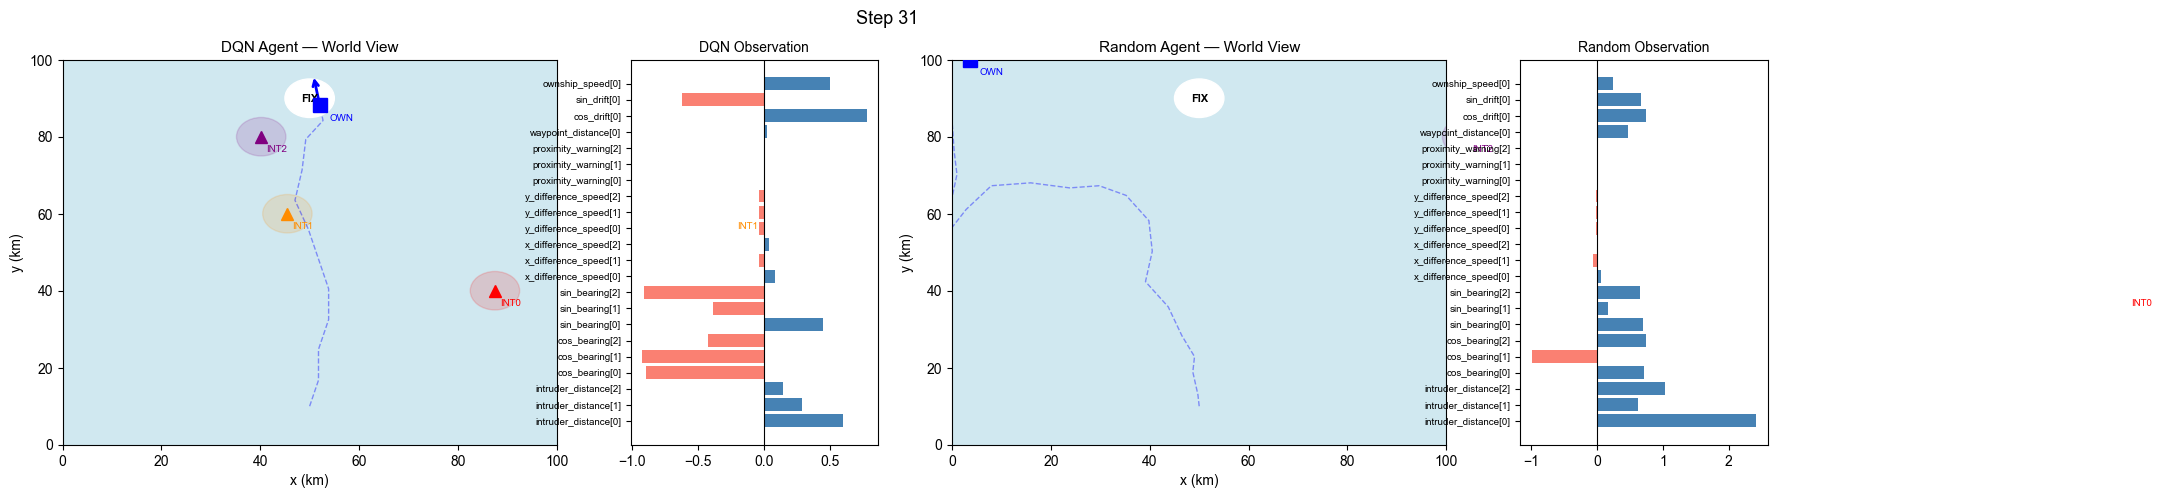

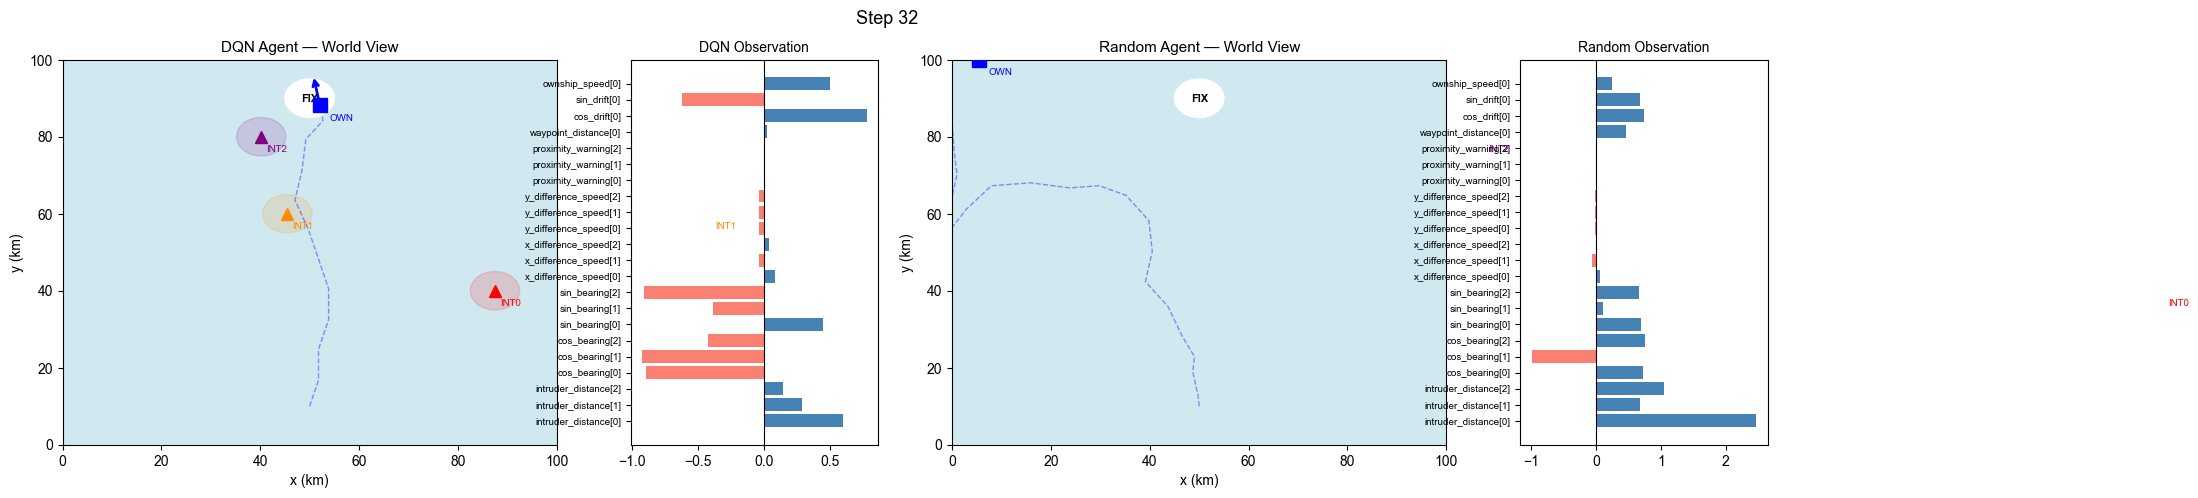

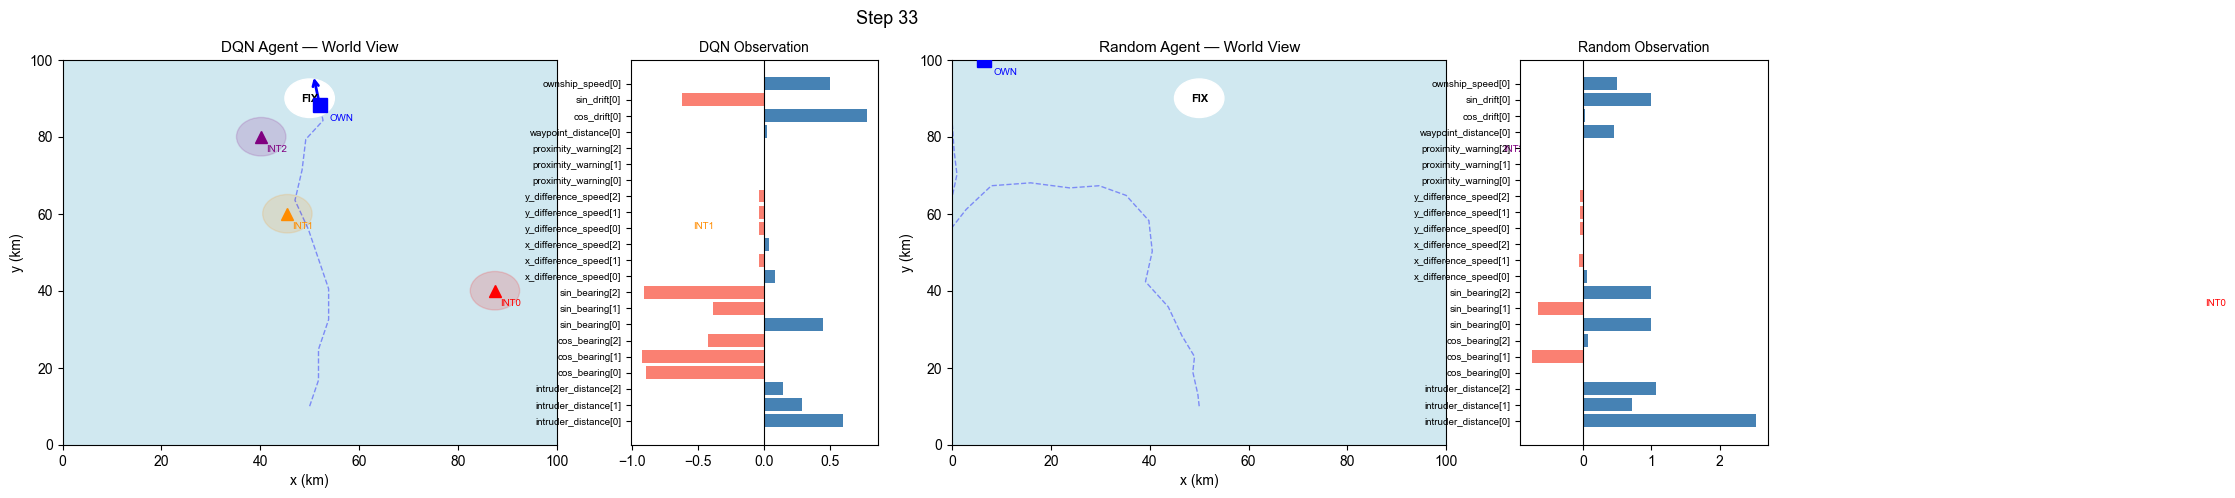

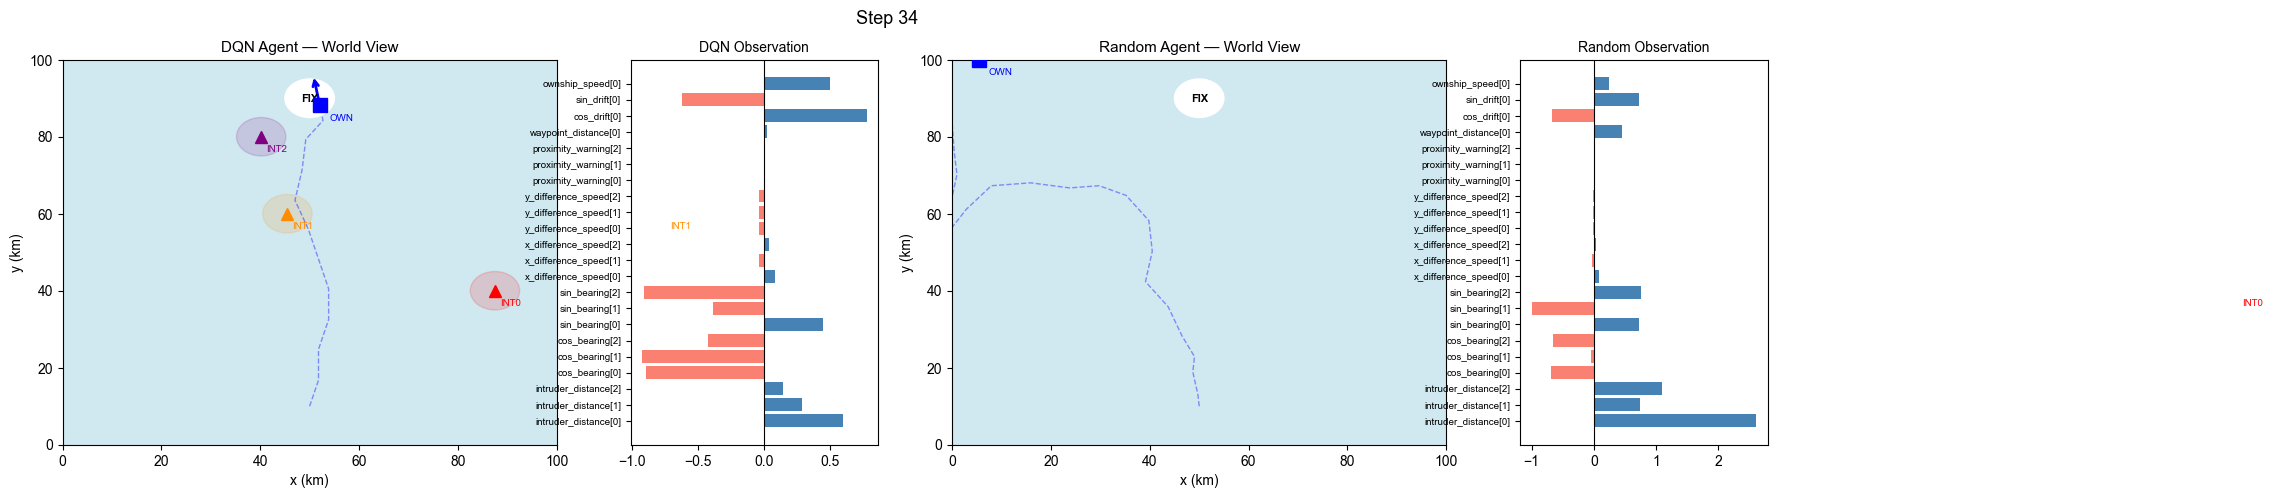

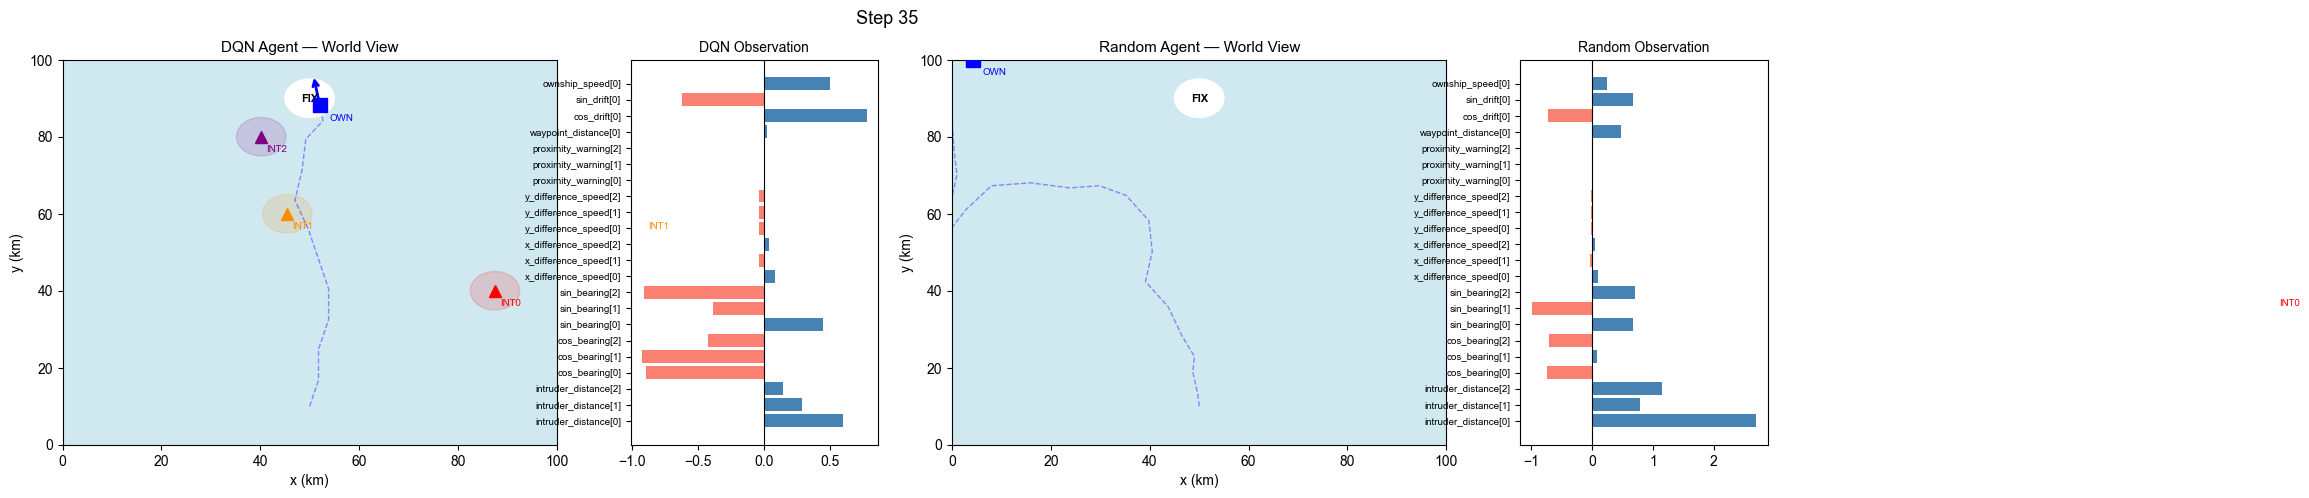

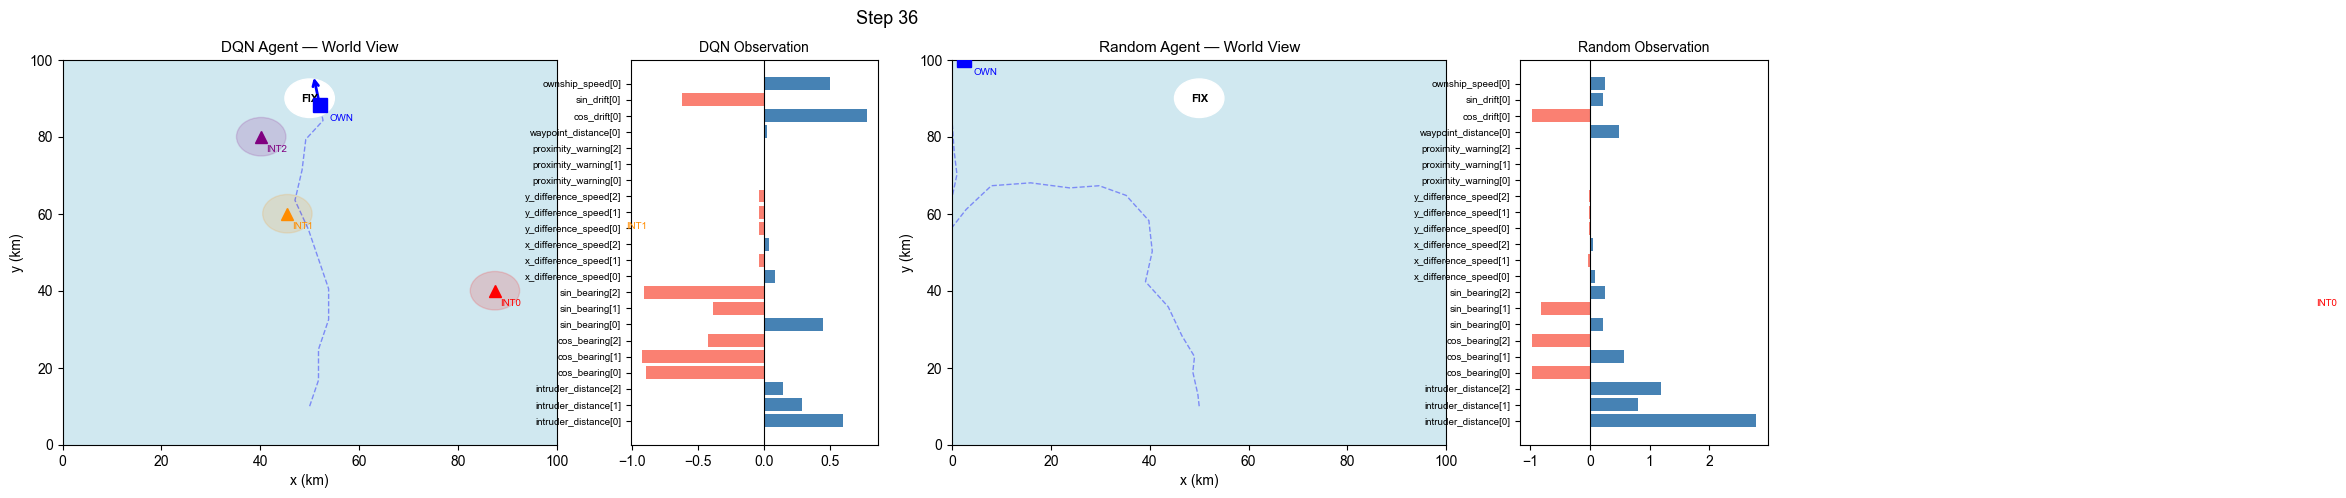

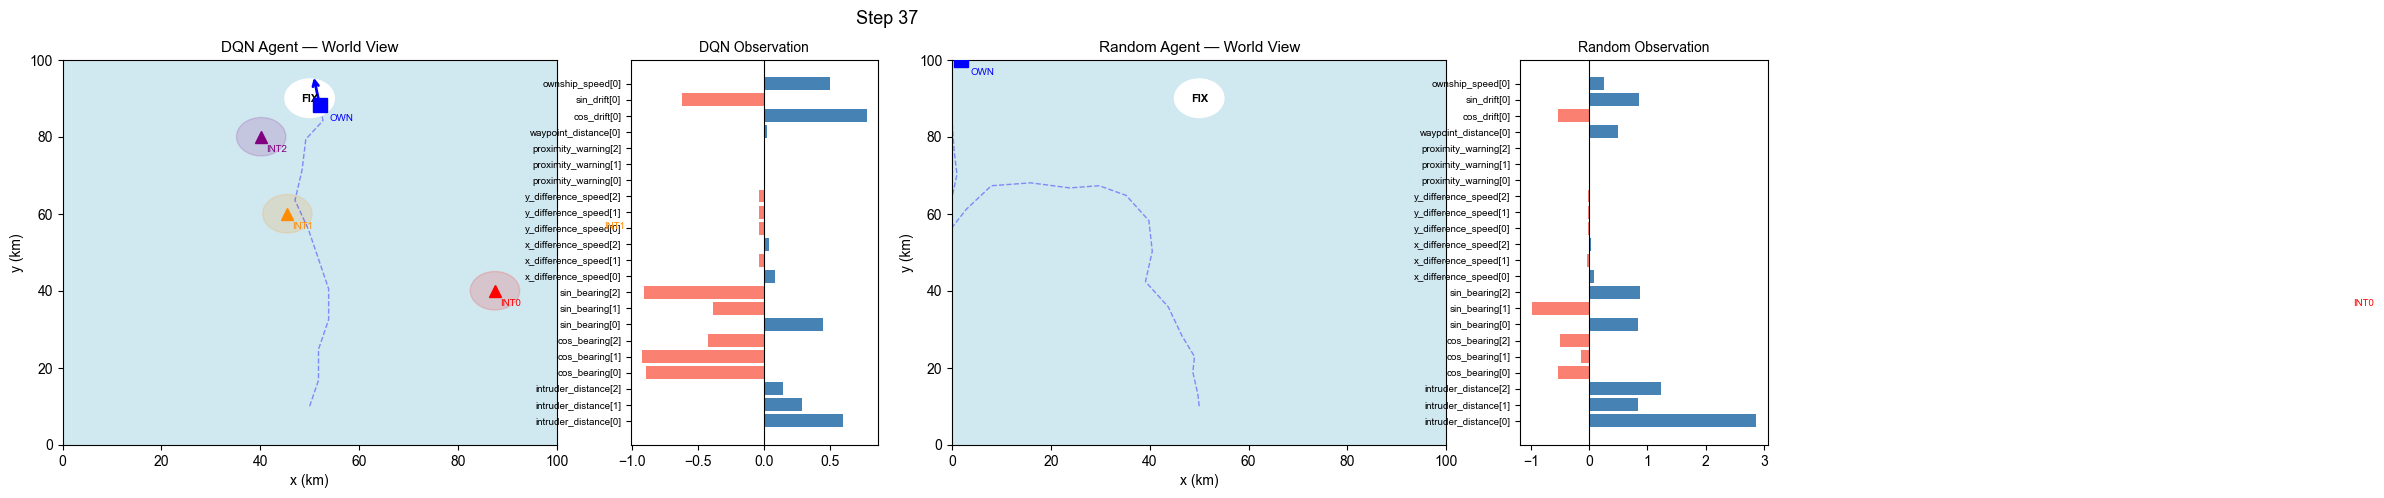

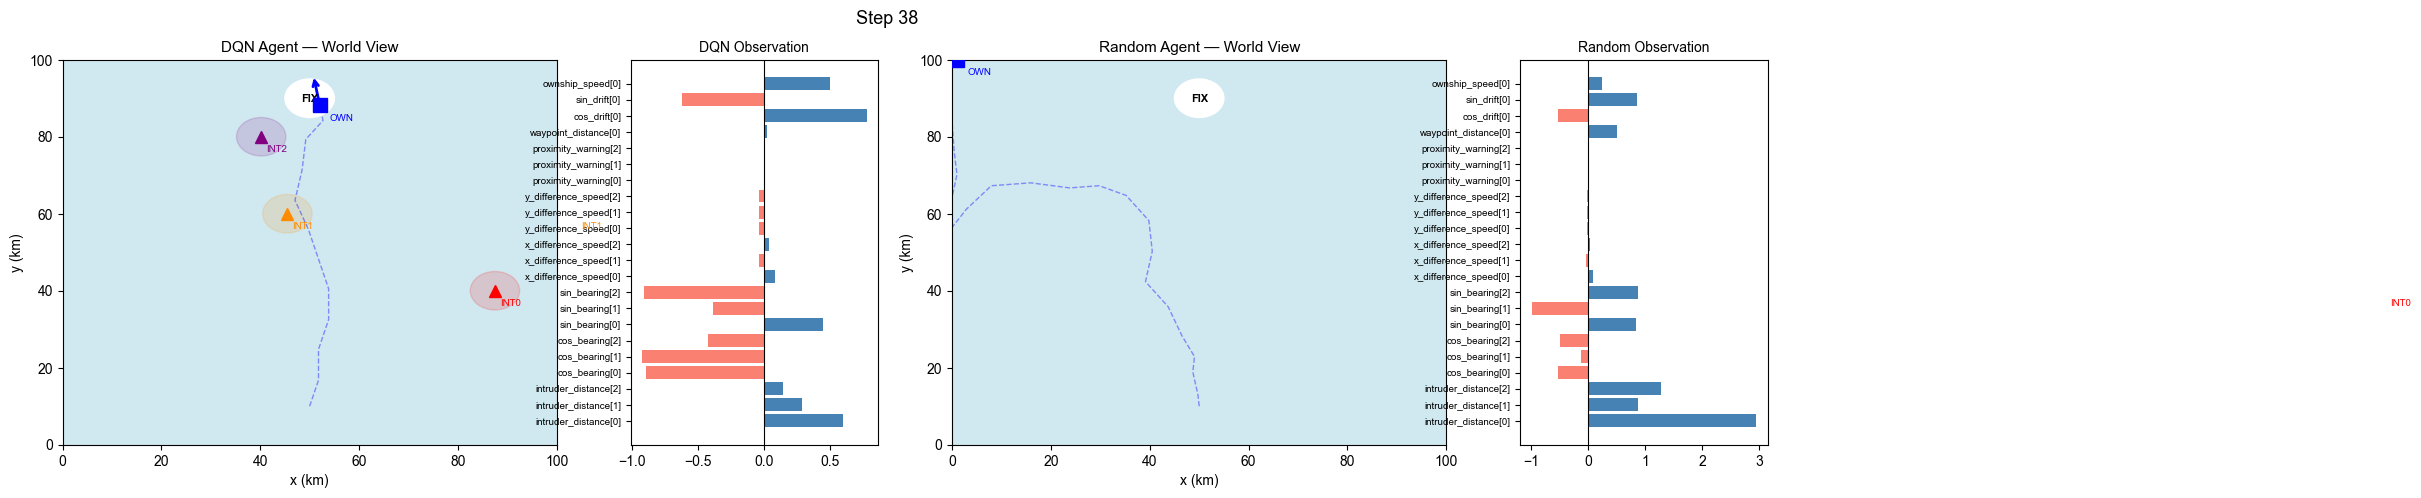

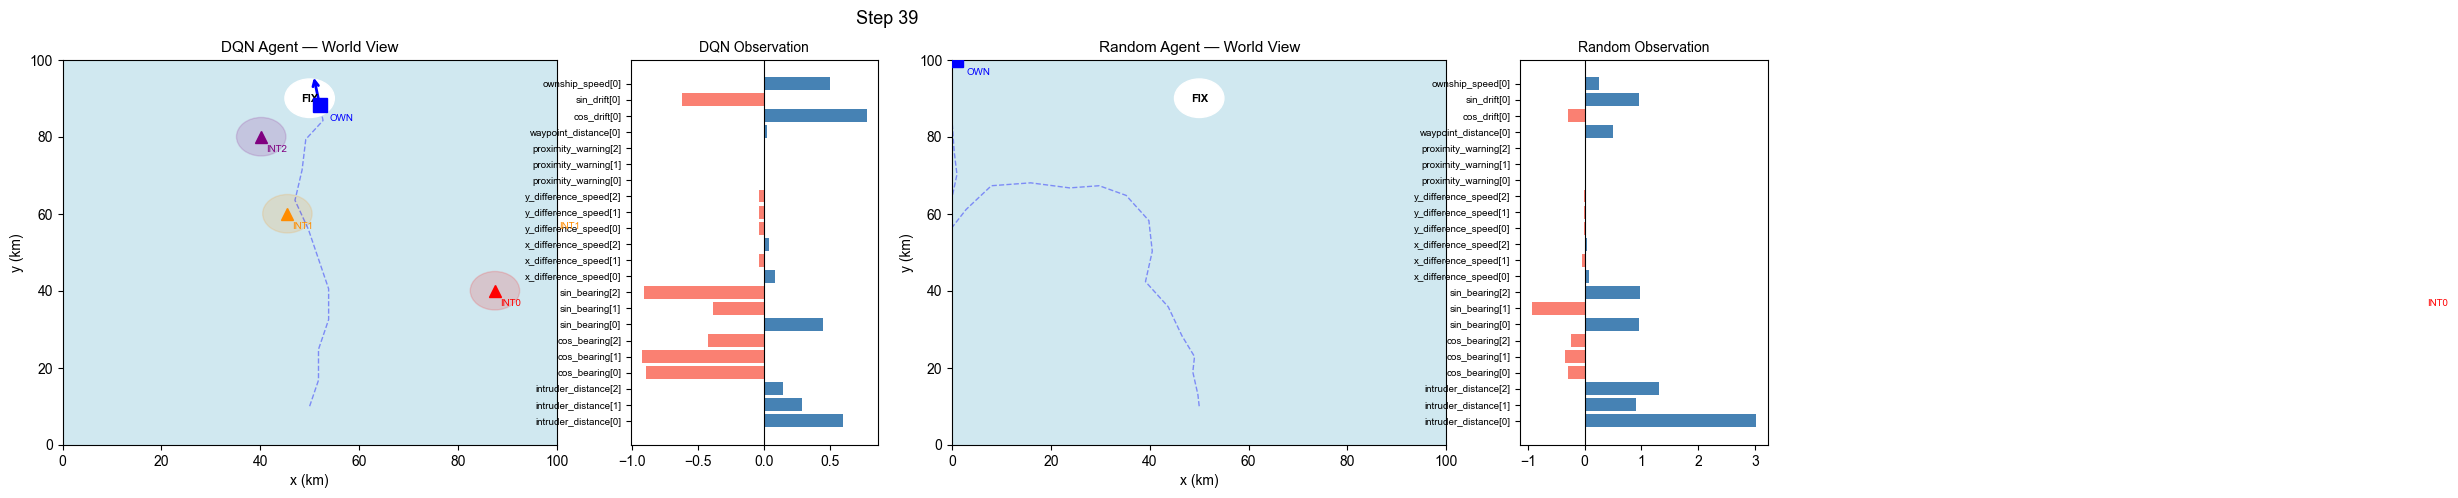

DQN    — reached=True  intrusions=0  steps=11
Random — reached=False  intrusions=0  steps=40


In [149]:
import matplotlib.patches as patches

def render_side_by_side(env_dqn, env_rnd, step_num):
    """Render both envs side by side at the current step."""
    fig, axes = plt.subplots(1, 4, figsize=(22, 5),
                             gridspec_kw={"width_ratios": [2, 1, 2, 1]})
    fig.suptitle(f"Step {step_num}", fontsize=13)

    def draw_world(ax, env, title):
        ax.set_xlim(0, env.world_size); ax.set_ylim(0, env.world_size)
        ax.set_facecolor("#d0e8f0")
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("x (km)"); ax.set_ylabel("y (km)")
        if len(env.history) > 1:
            traj = np.array([h["own"] for h in env.history])
            ax.plot(traj[:, 0], traj[:, 1], "b--", alpha=0.4, linewidth=1)
        ax.add_patch(patches.Circle(env.fix, env.reach_radius, color="white", zorder=3))
        ax.annotate("FIX", env.fix, ha="center", va="center",
                    fontsize=8, fontweight="bold", zorder=4)
        ox, oy = env.ownship_pos
        rad = np.deg2rad(env.ownship_hdg)
        ax.plot(ox, oy, "bs", markersize=10, zorder=5)
        ax.annotate("", xy=(ox + 8*np.sin(rad), oy + 8*np.cos(rad)), xytext=(ox, oy),
                    arrowprops=dict(arrowstyle="->", color="blue", lw=2))
        ax.text(ox+2, oy-4, "OWN", fontsize=7, color="blue")
        colors = ["red", "darkorange", "purple"]
        for i in range(NUM_INTRUDERS):
            ix, iy = env.intruder_pos[i]
            dist = np.linalg.norm(env.intruder_pos[i] - env.ownship_pos)
            c = "red" if dist < env.intrusion_radius else colors[i]
            ax.add_patch(patches.Circle((ix, iy), env.intrusion_radius, color=c, alpha=0.15))
            ax.plot(ix, iy, "^", color=c, markersize=9, zorder=5)
            ax.text(ix+1, iy-4, f"INT{i}", fontsize=7, color=c)

    def draw_obs(ax, env, title):
        obs_now = env._get_obs()
        labels, values = [], []
        for k, v in obs_now.items():
            for j, val in enumerate(v):
                labels.append(f"{k}[{j}]")
                values.append(float(val))
        bar_colors = ["steelblue" if v >= 0 else "salmon" for v in values]
        ax.barh(labels, values, color=bar_colors)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(title, fontsize=10)
        ax.tick_params(axis="y", labelsize=7)

    draw_world(axes[0], env_dqn, "DQN Agent — World View")
    draw_obs(axes[1], env_dqn,   "DQN Observation")
    draw_world(axes[2], env_rnd, "Random Agent — World View")
    draw_obs(axes[3], env_rnd,   "Random Observation")
    plt.tight_layout()
    plt.show()


def run_episode_stepwise(seed=42, scenario="blocked", max_steps=40):
    """Step both agents in sync and render each step."""
    env_dqn = DiscreteApproachEnv(scenario=scenario)
    env_rnd = DiscreteApproachEnv(scenario=scenario)
    obs_dqn, _ = env_dqn.reset(seed=seed)
    obs_rnd, _ = env_rnd.reset(seed=seed)

    done_dqn = done_rnd = False
    info_dqn = info_rnd = {}

    for step in range(max_steps):
        render_side_by_side(env_dqn.env, env_rnd.env, step)

        # stop as soon as either ownship reaches the fix
        if info_dqn.get("reached_fix") or info_rnd.get("reached_fix"):
            break

        if done_dqn and done_rnd:
            break

        if not done_dqn:
            action_dqn, _ = model.predict(obs_dqn, deterministic=True)
            obs_dqn, _, t_dqn, tr_dqn, info_dqn = env_dqn.step(action_dqn)
            done_dqn = t_dqn or tr_dqn

        if not done_rnd:
            action_rnd = env_rnd.action_space.sample()
            obs_rnd, _, t_rnd, tr_rnd, info_rnd = env_rnd.step(action_rnd)
            done_rnd = t_rnd or tr_rnd

    print(f"DQN    — reached={info_dqn.get('reached_fix')}  intrusions={info_dqn.get('total_intrusions')}  steps={info_dqn.get('step')}")
    print(f"Random — reached={info_rnd.get('reached_fix')}  intrusions={info_rnd.get('total_intrusions')}  steps={info_rnd.get('step')}")


run_episode_stepwise(seed=42, scenario="blocked")
